# 1. Import Libraries & Configuration

In [1]:
import math
import re
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor
)
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error,
    r2_score,
    root_mean_squared_error
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder,
    PolynomialFeatures
)
from category_encoders import TargetEncoder , LeaveOneOutEncoder
from catboost import CatBoostRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.model_selection import KFold, cross_val_score
import optuna
pd.options.display.float_format = '{:,.2f}'.format
pd.set_option('display.max_columns', None)
sns.set_style("whitegrid")

# 2. Load Dataset

In [2]:
df = pd.read_csv('/kaggle/input/turkish-used-cars-dataset-december-2025/turkey_used_cars.csv')

In [3]:
display(df.head())
print("\nDataset Info")
df.info()
print("\nMissing Values")
display(df.isna().sum())
print("\nDuplicate Rows:", df.duplicated().sum())
print("Dataset Shape:", df.shape)
print("\nStatistical Summary")
display(df.describe())

,brand,model,variant,year,km,color,price,city
0,audi,a1,1.4 TFSI Attraction,2011,155000,White,625000,İstanbul
1,audi,a1,1.6 TDI Ambition,2011,252000,Black,625000,Aydın
2,audi,a1,1.4 TFSI Attraction,2012,203000,Black,665000,Zonguldak
3,audi,a1,1.6 TDI Ambition,2013,270000,White,835000,İstanbul
4,audi,a1,1.6 TDI Attraction,2011,228000,Black,670000,Ankara



Dataset Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 253344 entries, 0 to 253343
Data columns (total 8 columns):
 #   Column   Non-Null Count   Dtype 
---  ------   --------------   ----- 
 0   brand    253344 non-null  object
 1   model    253344 non-null  object
 2   variant  253344 non-null  object
 3   year     253344 non-null  int64 
 4   km       253344 non-null  int64 
 5   color    253344 non-null  object
 6   price    253344 non-null  int64 
 7   city     253344 non-null  object
dtypes: int64(3), object(5)
memory usage: 15.5+ MB

Missing Values


brand      0
model      0
variant    0
year       0
km         0
color      0
price      0
city       0
dtype: int64


Duplicate Rows: 288
Dataset Shape: (253344, 8)

Statistical Summary


,year,km,price
count,"253,344.00","253,344.00","253,344.00"
mean,"2,013.97","168,128.63","1,115,799.86"
std,6.52,"76,662.11","974,430.64"
min,"1,972.00",0.00,"100,000.00"
25%,"2,011.00","110,000.00","575,000.00"
50%,"2,015.00","174,000.00","880,000.00"
75%,"2,019.00","230,000.00","1,300,000.00"
max,"2,025.00","300,000.00","10,000,000.00"


 Clean dataset with no missing values and a manageable number of duplicates.
 
 Mileage and price distributions are highly spread, suggesting outlier analysis is needed.
 
 The dataset is large enough for robust statistical and ML modeling.


# 3. Remove Duplicates

In [4]:
df.drop_duplicates(inplace=True,ignore_index=True)
df.shape

(253056, 8)

We can remove the few duplicated entries, as they are minimal.

# 4. Exploratory Data Analysis (EDA)

## 4.1 Price Distribution

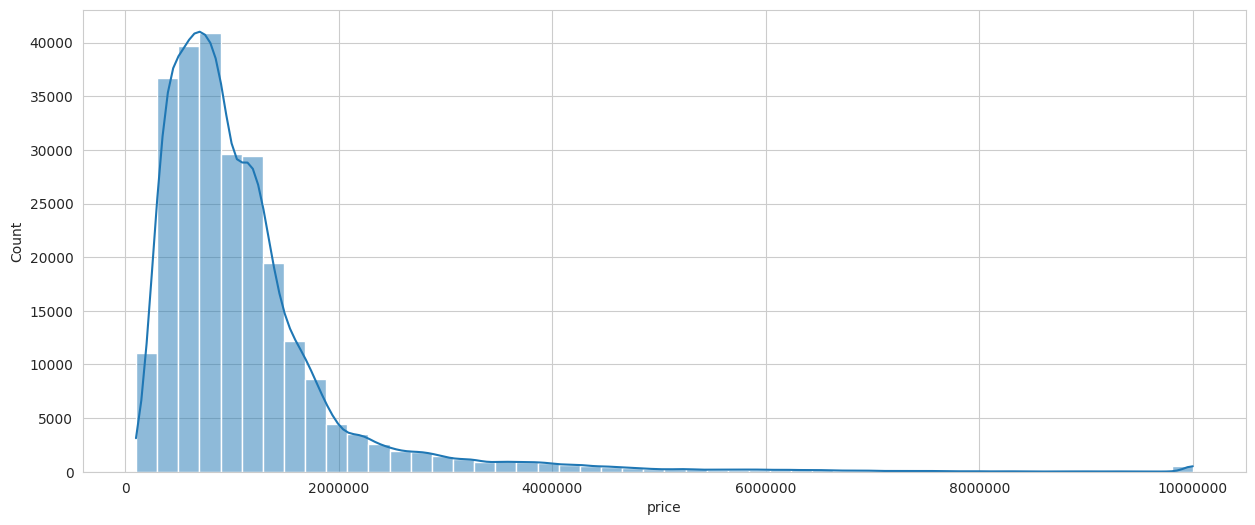

In [5]:
plt.figure(figsize=(15,6))
sns.histplot(data=df['price'] , bins=50, kde=True)
plt.ticklabel_format(style='plain' , axis='x')
plt.show()

The price distribution appears right-skewed, as expected, with the majority of listings clustered below 2 million. This suggests that our models will likely perform better at predicting mid-range prices. Applying a log transformation to the price and using it as the target variable seems to be a more sensible approach.


## 4.2 KM Distribution

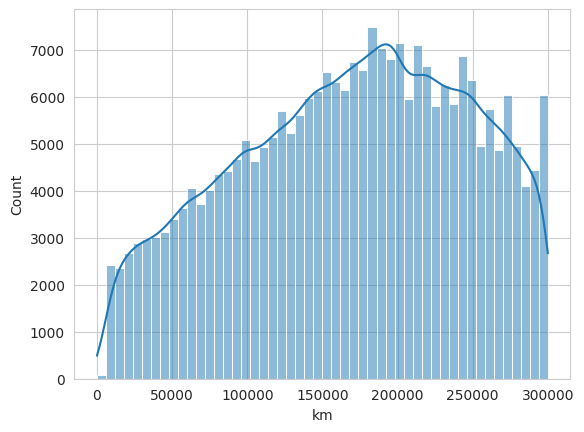

In [6]:
sns.histplot(data=df['km'], bins=50 , kde=True)
plt.show()

The mileage distribution is generally concentrated between 150,000 and 250,000 km and appears approximately normally distributed.

## 4.3 Price vs KM

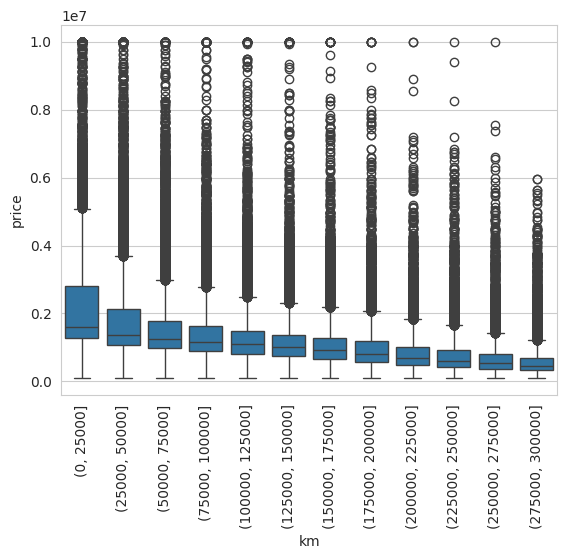

In [7]:
sns.boxplot(
    x=pd.cut(df['km'], bins=range(0, df['km'].max()+25000, 25000)),
    y=df['price']
)
plt.xticks(rotation=90)
plt.show()

By examining the median values and the width of the boxes, we can observe that, in general, as mileage increases, the price tends to decrease.

## 4.4 Price vs Year

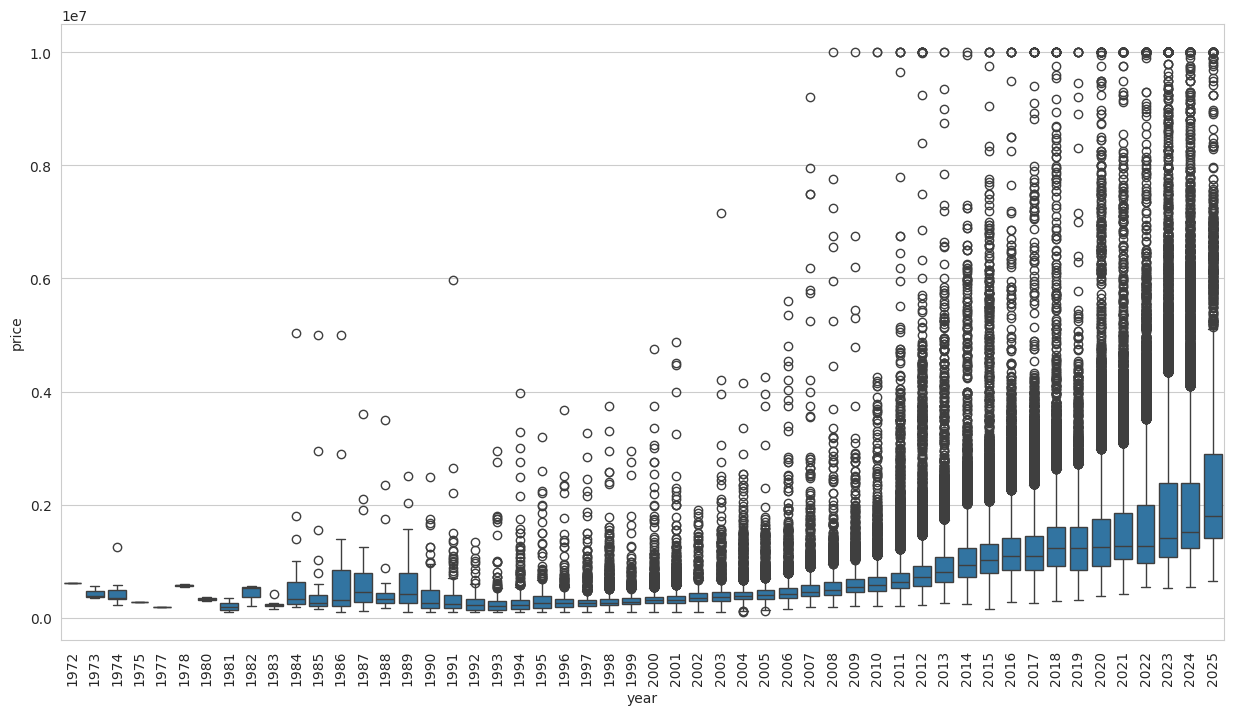

In [8]:
plt.figure(figsize=(15,8))
sns.boxplot(data=df , x='year' , y='price')
plt.xticks(rotation=90)
plt.show()

As clearly observed, the price increases with the car's production year. There are also noticeable outliers among both older and newer vehicles, which may require attention to ensure model reliability.

## 4.5 Price vs Brand

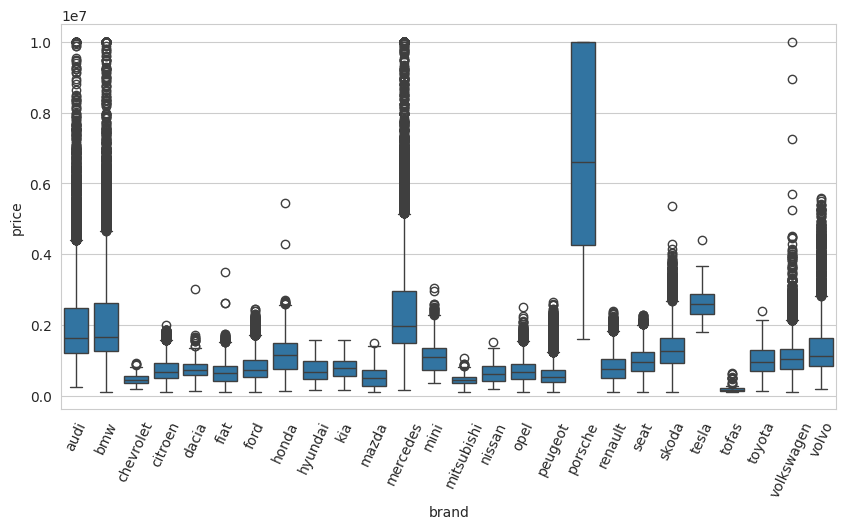

In [9]:
plt.figure(figsize=(10,5))
sns.boxplot(data=df , x='brand' ,y='price')
plt.xticks(rotation=65)
plt.show()

The differences between brand segments are clearly visible—for example, luxury brands like Audi, BMW, and Mercedes versus mid-range brands like Volkswagen and Škoda. Within each brand, there are also outliers, which we plan to handle using group-based outlier treatment. Additionally, since prices in the raw data are clipped between 100,000 and 10,000,000 TL, there appears to be a concentration at the upper limit of 10 million.

## 4.6 Price vs City

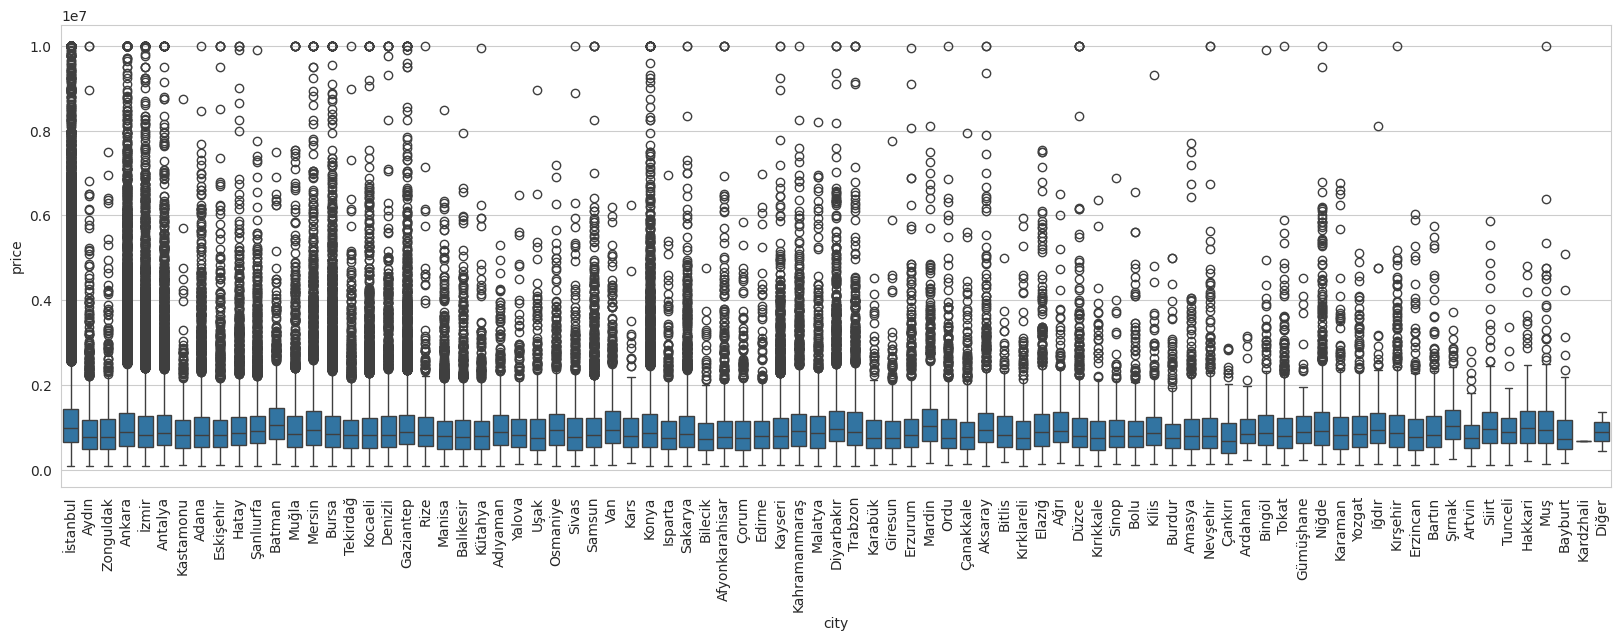

In [10]:
plt.figure(figsize=(20,6))
sns.boxplot(data=df , x='city' , y='price')
plt.xticks(rotation=90)
plt.show()

In terms of price density, larger cities are more prominent, but prices are generally similar across most cities, with a few exceptions.

## 4.7 Price vs Color

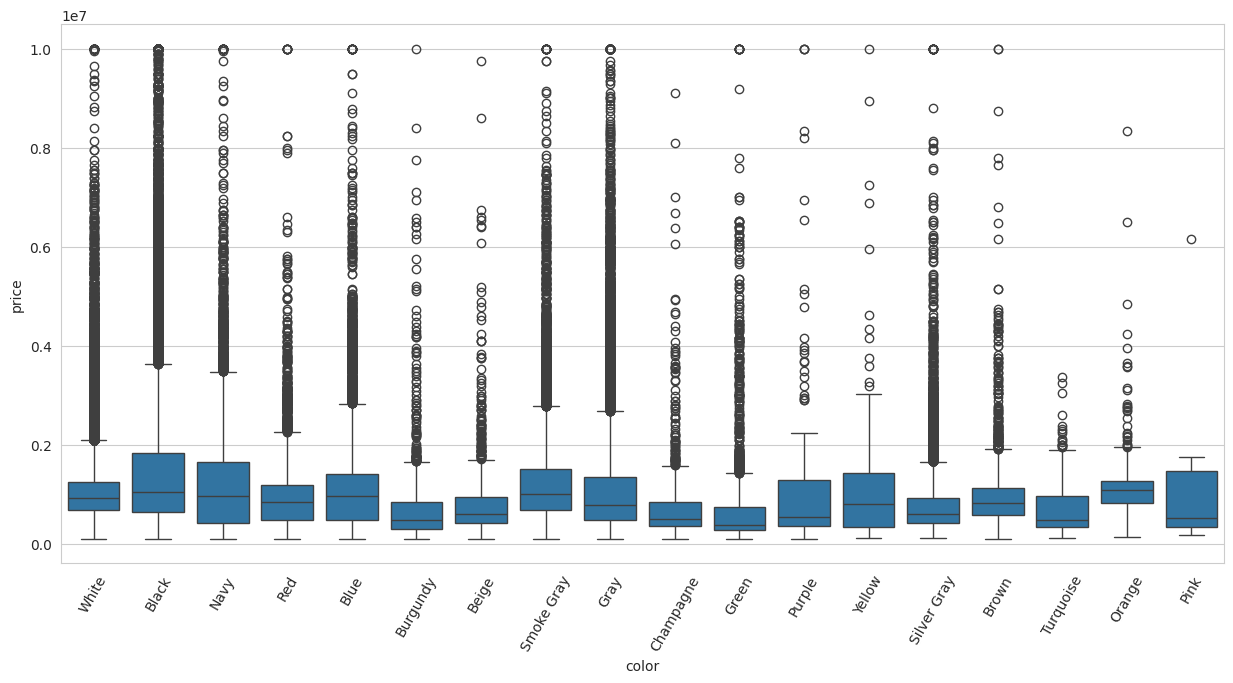

In [11]:
plt.figure(figsize=(15,7))
sns.boxplot(data=df , x='color' , y='price')
plt.xticks(rotation=60)
plt.show()

Color does not seem to be a particularly important feature, similar to the city variable. We can simplify it by grouping into the top 5 colors and an “Other” category.

# 5. Feature Engineering

In [12]:
dfx = df.copy()

I am creating a new DataFrame called `dfx` by copying `df`, so that experiments can be conducted on `dfx` without affecting the original dataset. After evaluating and selecting the appropriate preprocessing steps, I will apply them to the main DataFrame before modeling.

## 5.1 Car Age Feature And KM Floor Adjustment

In [13]:
year_now = 2025
dfx['car_age'] = (year_now + 1) - dfx['year']
dfx.loc[dfx['km'] < 5000, 'km'] = 5000

Replacing `year` with a `car_age` column makes more sense from a modeling perspective. Additionally, trimming entries with mileage below 5,000 km helps protect against misleading listings, such as 0 or 1 km, which are common on second-hand car websites.

In [14]:
dfx.describe()

,year,km,price,car_age
count,"253,056.00","253,056.00","253,056.00","253,056.00"
mean,"2,013.97","168,182.80","1,114,218.80",12.03
std,6.52,"76,628.55","967,831.64",6.52
min,"1,972.00","5,000.00","100,000.00",1.00
25%,"2,011.00","110,000.00","575,000.00",7.00
50%,"2,015.00","174,000.00","880,000.00",11.00
75%,"2,019.00","230,000.00","1,300,000.00",15.00
max,"2,025.00","300,000.00","10,000,000.00",54.00


## 5.2 City → Region Mapping

In [15]:
region_map = {
    # Marmara (11)
    "İstanbul": "Marmara",
    "Edirne": "Marmara",
    "Kırklareli": "Marmara",
    "Tekirdağ": "Marmara",
    "Çanakkale": "Marmara",
    "Balıkesir": "Marmara",
    "Bursa": "Marmara",
    "Yalova": "Marmara",
    "Kocaeli": "Marmara",
    "Sakarya": "Marmara",
    "Bilecik": "Marmara",

    # Ege (8)
    "İzmir": "Ege",
    "Manisa": "Ege",
    "Aydın": "Ege",
    "Denizli": "Ege",
    "Muğla": "Ege",
    "Uşak": "Ege",
    "Kütahya": "Ege",
    "Afyonkarahisar": "Ege",

    # Akdeniz (8)
    "Antalya": "Akdeniz",
    "Isparta": "Akdeniz",
    "Burdur": "Akdeniz",
    "Adana": "Akdeniz",
    "Mersin": "Akdeniz",
    "Hatay": "Akdeniz",
    "Kahramanmaraş": "Akdeniz",
    "Osmaniye": "Akdeniz",

    # İç Anadolu (13)
    "Ankara": "İç Anadolu",
    "Eskişehir": "İç Anadolu",
    "Konya": "İç Anadolu",
    "Aksaray": "İç Anadolu",
    "Karaman": "İç Anadolu",
    "Kırıkkale": "İç Anadolu",
    "Kırşehir": "İç Anadolu",
    "Nevşehir": "İç Anadolu",
    "Niğde": "İç Anadolu",
    "Yozgat": "İç Anadolu",
    "Çankırı": "İç Anadolu",
    "Kayseri": "İç Anadolu",
    "Sivas": "İç Anadolu",

    # Karadeniz (17)
    "Bolu": "Karadeniz",
    "Düzce": "Karadeniz",
    "Zonguldak": "Karadeniz",
    "Bartın": "Karadeniz",
    "Karabük": "Karadeniz",
    "Kastamonu": "Karadeniz",
    "Sinop": "Karadeniz",
    "Samsun": "Karadeniz",
    "Çorum": "Karadeniz",
    "Amasya": "Karadeniz",
    "Tokat": "Karadeniz",
    "Ordu": "Karadeniz",
    "Giresun": "Karadeniz",
    "Trabzon": "Karadeniz",
    "Rize": "Karadeniz",
    "Artvin": "Karadeniz",
    "Gümüşhane": "Karadeniz",
    

    # Doğu Anadolu (15)
    "Erzincan": "Doğu Anadolu",
    "Erzurum": "Doğu Anadolu",
    "Bayburt": "Doğu Anadolu",
    "Ağrı": "Doğu Anadolu",
    "Kars": "Doğu Anadolu",
    "Iğdır": "Doğu Anadolu",
    "Ardahan": "Doğu Anadolu",
    "Van": "Doğu Anadolu",
    "Muş": "Doğu Anadolu",
    "Bitlis": "Doğu Anadolu",
    "Hakkari": "Doğu Anadolu",
    "Malatya": "Doğu Anadolu",
    "Elazığ": "Doğu Anadolu",
    "Tunceli": "Doğu Anadolu",
    "Bingöl": "Doğu Anadolu",

    # Güneydoğu Anadolu (9)
    "Gaziantep": "Güneydoğu Anadolu",
    "Adıyaman": "Güneydoğu Anadolu",
    "Şanlıurfa": "Güneydoğu Anadolu",
    "Diyarbakır": "Güneydoğu Anadolu",
    "Mardin": "Güneydoğu Anadolu",
    "Batman": "Güneydoğu Anadolu",
    "Siirt": "Güneydoğu Anadolu",
    "Şırnak": "Güneydoğu Anadolu",
    "Kilis": "Güneydoğu Anadolu"
}

In [16]:
dfx["region"] = dfx["city"].map(region_map)
dfx['region'].unique()

array(['Marmara', 'Ege', 'Karadeniz', 'İç Anadolu', 'Akdeniz',
       'Güneydoğu Anadolu', 'Doğu Anadolu', nan], dtype=object)

Dropping the `city` column and replacing it with a `region` column is an important step to reduce cardinality. While we could have applied a top-5/“Other” grouping like with the color feature, using `region` allows us to incorporate socioeconomic context. At the same time, it keeps the feature low-cardinality for the model.

In [17]:
dfx[dfx["region"].isna()]["city"].unique()

array(['Kardzhali', 'Diğer'], dtype=object)

In [18]:
dfx[dfx["city"].isin(["Kardzhali", "Diğer"])]["city"].value_counts()

city
Diğer        2
Kardzhali    1
Name: count, dtype: int64

In [19]:
dfx = dfx[~dfx["city"].isin(["Diğer", "Kardzhali"])]
dfx[dfx["region"].isna()]["city"].unique()

array([], dtype=object)

I am checking for cities that do not exist in Turkey or listings where the city was not provided. The entries identified through this check are being removed, as they are incorrectly entered. Although imputation could have been considered, the number of such cases is negligible, so they can be safely ignored.

## 5.3 Color Reduction (Top 5)

In [20]:
top5 = dfx['color'].value_counts().nlargest(5).index
dfx['color'] = dfx['color'].apply(lambda x: x if x in top5 else 'Other')

As mentioned earlier, I am keeping the top 5 colors and grouping the rest as “Other” to reduce cardinality.

## 5.4 Engine CC Extraction

In [21]:
dfx['variant'].value_counts()

variant
1.6 TDI BlueMotion Comfortline    4535
1.5 dCi Touch                     3565
1.3 Multijet Easy                 3533
1.6 TDI Comfortline               2623
1.6i VTEC Eco Elegance            2437
                                  ... 
1.4 CL                               2
1.5 GT                               1
1.6  Style                           1
2.0 HDi SV                           1
2.0 Sport Trend                      1
Name: count, Length: 2118, dtype: int64

There are 2,118 unique variants, and some occur only once, twice, or five times, which could negatively impact the model. However, these variants contain useful information, such as engine size, which we can extract later. Given the limited dataset, creating additional features from these variants could benefit the model. For example, fuel type (diesel, petrol, etc.) could be inferred from terms like TDI or TSI, but this approach would generate many missing values due to inconsistent naming conventions across brands.

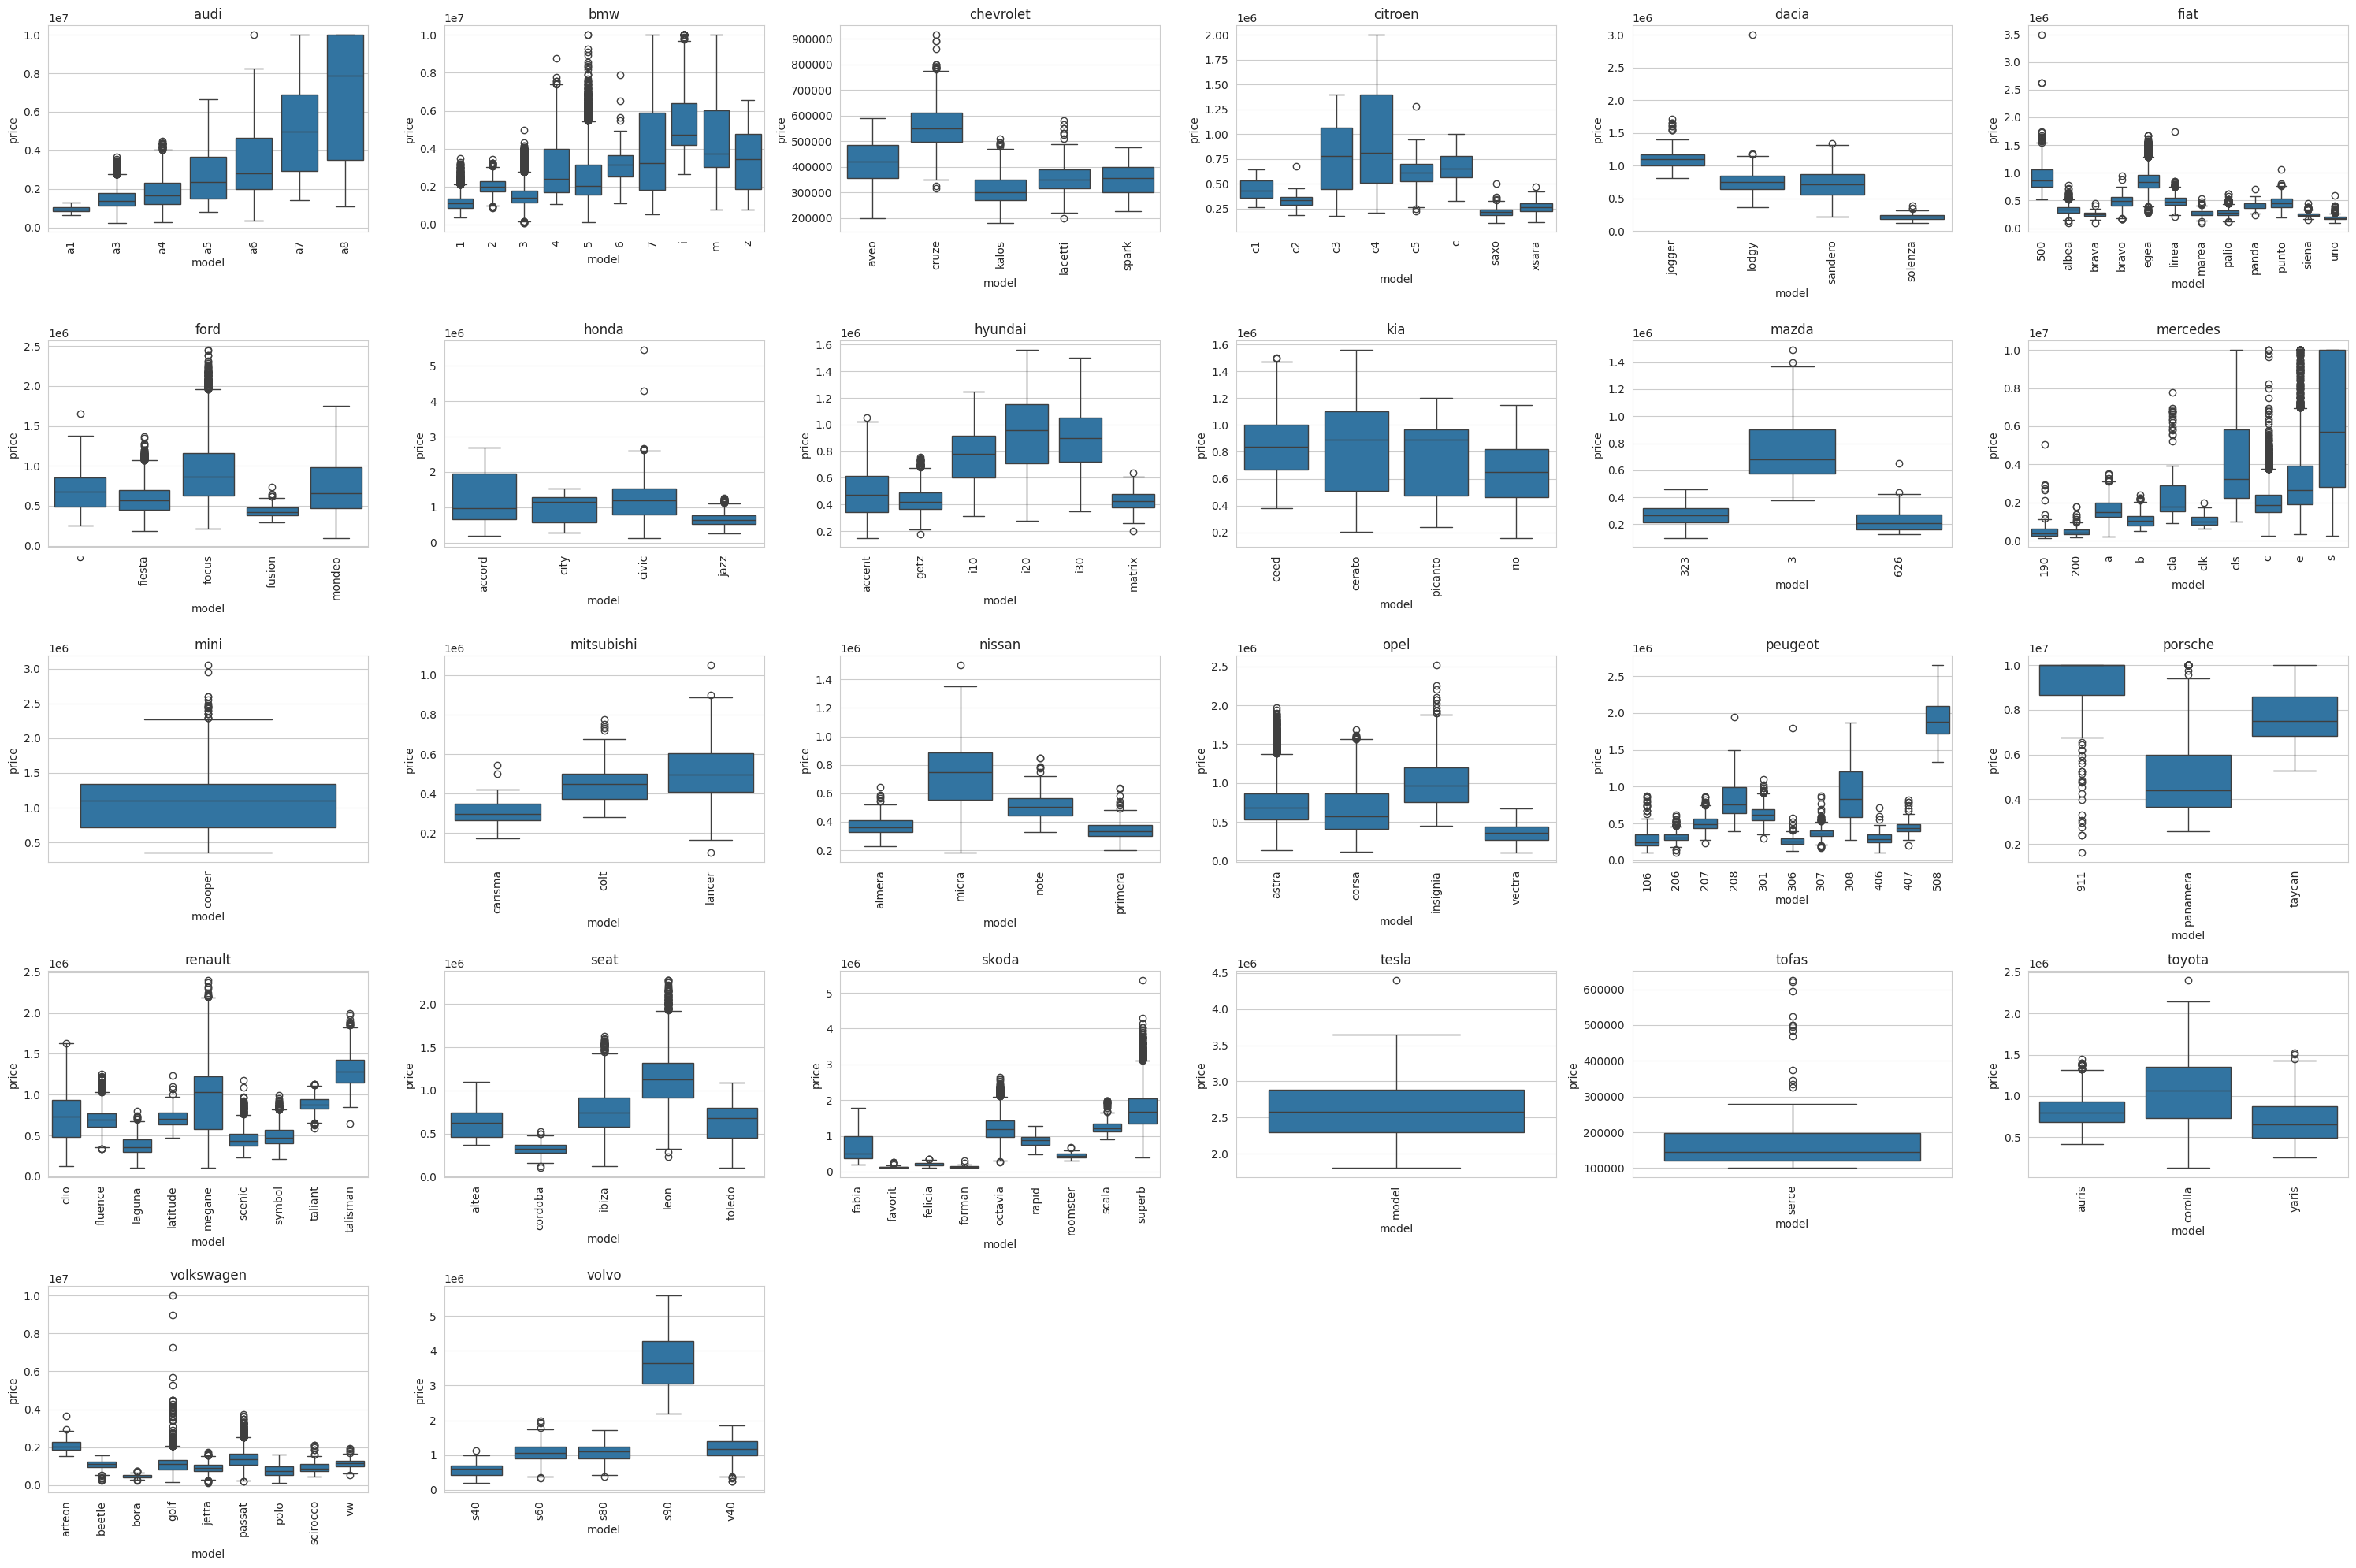

In [22]:
brands = dfx['brand'].unique()
n_brands = len(brands)
n_cols = math.ceil(math.sqrt(n_brands))
n_rows = math.ceil(n_brands / n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 4*n_rows))
axes = axes.flatten()
for i, brand in enumerate(brands):
    brand_df = dfx[dfx['brand'] == brand]
    sns.boxplot(
        data=brand_df,
        x='model',
        y='price',
        ax=axes[i]
    )
    axes[i].set_title(brand)
    axes[i].tick_params(axis='x', rotation=90)
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.show()

Some brands, such as Tesla or Tofaş, have only a single model, so I plan to drop them later, as their price ranges are very clear. Within each brand, vehicles naturally fall into low, mid, and high segments. A good example is Audi, where each model’s price increases roughly linearly. In the next steps, we can perform IQR-based outlier cleaning grouped by brand, model, and year to remove exaggerated listings, replacing extreme values with the median to minimize data loss. Additionally, since the dataset does not include information on heavily damaged vehicles, this approach will effectively adjust prices upwards for any potentially damaged cars using the lower bound.

In [23]:
def variant_group_info(dfx):
    vgi_list = []
    for brand, group in dfx.groupby("brand"):
        unique_variants = group["variant"].dropna().unique()
        vgi_s = (
            f"{brand} counts "
            f"{len(unique_variants)} counts of unique variants.\n\n"
            f"variant:\n- " + "\n- ".join(sorted(unique_variants))
        )
        vgi_list.append(vgi_s)
    return "\n\n" + "="*80 + "\n\n".join(vgi_list)

Since engine information varies from brand to brand, I first need to examine the variant details within each brand’s models. For example, a Volkswagen Polo might be listed as “1.4 TDI Trendline,” while a BMW 3 Series could be “116i.” Because of these differences, it’s not feasible to write a universal extraction code.

In [24]:
print(variant_group_info(dfx)[:10])

In [25]:
dfx["engine_raw"] = dfx["variant"].str.extract(r'(\d\.\d)')
dfx["engine_cc"] = (
    dfx["engine_raw"]
    .str.replace(".", "", regex=False)
    .astype(float)
    .mul(100)
)
dfx["engine_cc"] = dfx["engine_cc"].fillna("unknown")
dfx.drop(columns="engine_raw", inplace=True)

In general, we can write code to handle all variants collectively, but for brand-specific cases like BMW, a separate, customized approach will be required.

In [26]:
dfx.loc[dfx['engine_cc'] == 'unknown', 'brand'].value_counts()

brand
bmw         18330
mercedes    14195
audi         3574
tesla         785
porsche       767
fiat          648
peugeot       256
tofas         141
skoda         136
Name: count, dtype: int64

For Audi, the general extraction code works for most variants, but some, like “A3 Sedan 45 TFSI,” don’t follow the pattern. In this example, it’s not actually a 4,500 cc engine, so there’s no reliable way to extract engine size from such entries. These cases will need to be set as NaN for now. Moving forward, I will focus on extracting engine information as accurately as possible for BMW and Mercedes.

In [27]:
def extract_bmw_engine_cc(row):
    if row["brand"] != "bmw":
        return row["engine_cc"]
    if not isinstance(row["engine_cc"], str):
        return row["engine_cc"]
    variant = str(row["variant"]).lower()
    match = re.search(r"(\d{3})", variant)
    if not match:
        return "unknown"
    code = match.group(1)
    return int(code[1:]) * 100

Some variants are listed simply as “320,” while others include letters, like “116i.” Therefore, the regex needs to be carefully designed to correctly capture the engine information without misinterpreting the letters.

In [28]:
dfx["engine_cc"] = dfx.apply(extract_bmw_engine_cc, axis=1)

In [29]:
def extract_mercedes_cc(row):
    if row['brand'].lower() != 'mercedes':
        return row['engine_cc'] 
    if row['engine_cc'] != 'unknown':
        return row['engine_cc']
    matches = re.findall(r'\b(\d{3})\b', row['variant'])
    if matches:
        return int(matches[0]) * 10
    else:
        return 'unknown'
dfx['engine_cc'] = dfx.apply(extract_mercedes_cc, axis=1)

In [30]:
dfx["engine_cc"] = pd.to_numeric(dfx["engine_cc"], errors="coerce")

In [31]:
dfx = dfx[~dfx['brand'].isin(['tesla', 'tofas' , 'porsche' , 'mini'])]

While plotting by brand and model, we observed that some brands have only a single model. Therefore, I am removing these entries.

## 5.5 Rare Variant Grouping

In [32]:
((dfx['variant'].value_counts()) < 30 ).sum()

np.int64(919)

In [33]:
variant_counts = dfx['variant'].value_counts()
dfx['variant'] = dfx['variant'].apply(lambda x: x if variant_counts[x] >= 30 else 'rare_variant')

To reduce the cardinality of the `variant` feature to some extent, I set a threshold of 30, which covers approximately 50% of the data. Since we plan to apply median replacement, prices in very small groups would not be reliable, so excluding them helps maintain more realistic values.

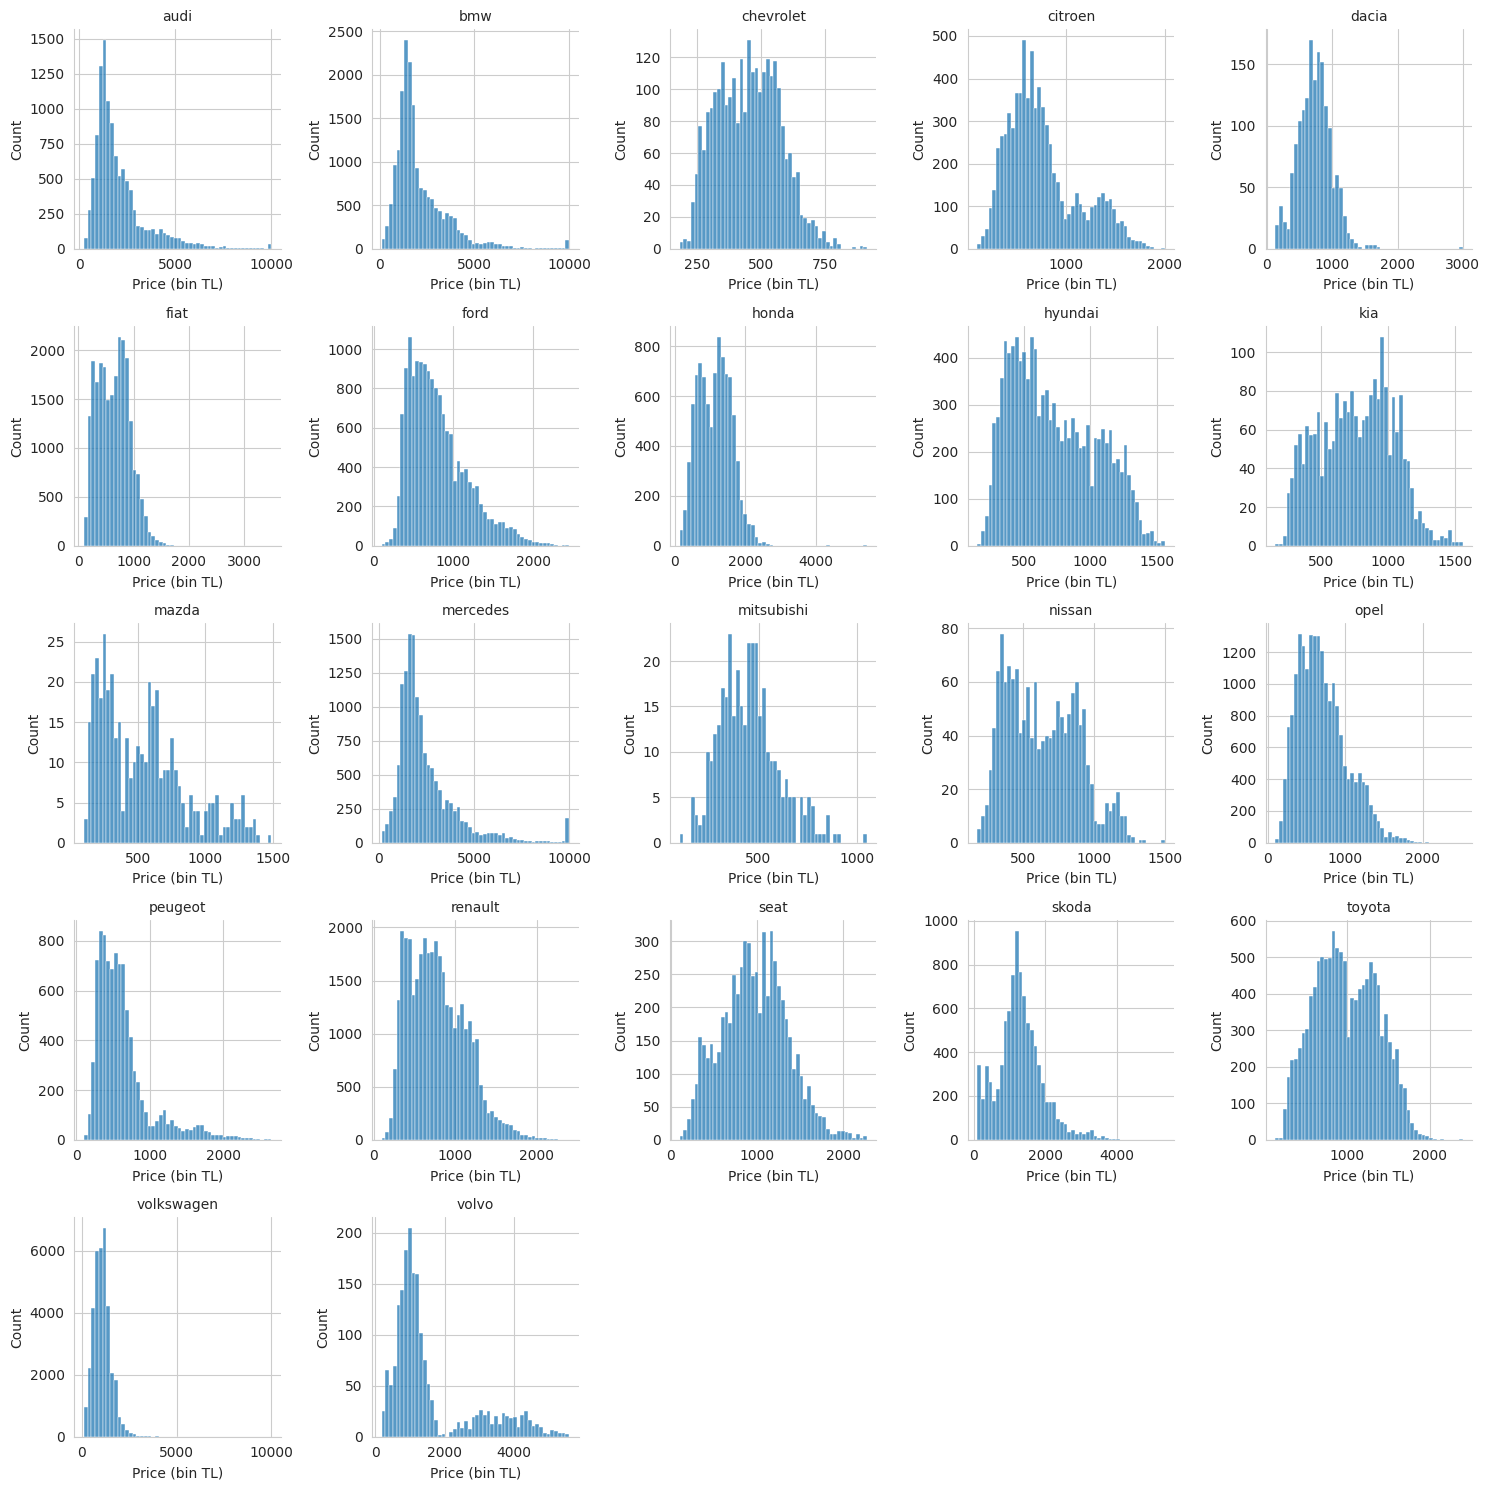

In [34]:
def thousands_formatter(x, pos):
    return f"{int(x/1000)}"
all_brands = dfx['brand'].value_counts().index
g = sns.FacetGrid(
    dfx[dfx['brand'].isin(all_brands)],
    col="brand",
    col_wrap=5,
    height=3,
    sharex=False,
    sharey=False
)
g.map_dataframe(sns.histplot, x="price", bins=50)
for ax in g.axes.flatten():
    ax.xaxis.set_major_formatter(FuncFormatter(thousands_formatter))
    ax.set_xlabel("Price (bin TL)")
g.set_titles("{col_name}")
g.tight_layout()
plt.show()

Some brands, such as Audi, exhibit right-skewed distributions due to high price variability within the brand. Others, like Volkswagen, may contain incorrect or potentially fake listings, while brands such as Toyota appear to follow a more normal distribution. We can revisit this visualization during later stages of outlier handling, and potentially apply a brand-level 0.99 quantile-based cleaning after the initial outlier removal.

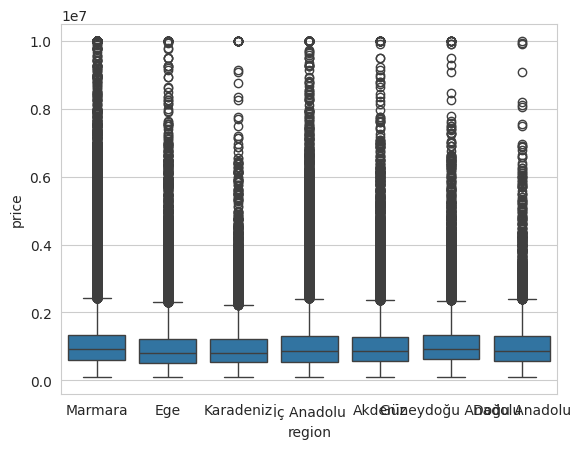

In [35]:
sns.boxplot(data=dfx , x='region' , y='price')
plt.show()

When examining the region vs. price plot, we can observe that the groups containing Ankara and Istanbul dominate the distribution.

## 5.6 Log Transformation (Target)

In [36]:
dfx['log_price'] = np.log1p(dfx['price'])

Since the price distribution is highly right-skewed, using `log_price` would be a much more appropriate choice, both for clearer visualizations and improved model performance.

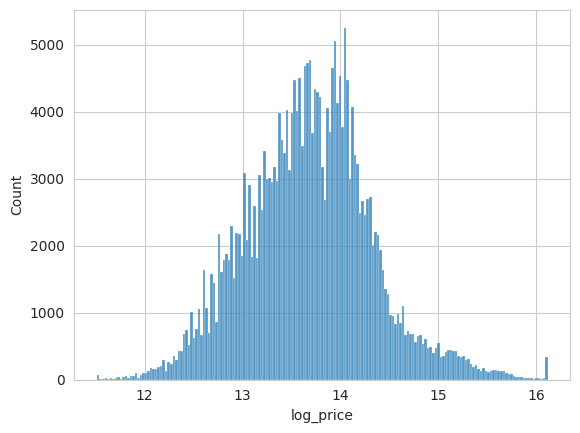

In [37]:
sns.histplot(data=dfx,x='log_price')
plt.show()

As seen in the plot, applying the transformation effectively brings the target variable (`price`) closer to a normal distribution. However, there are still some noticeable concentrations, particularly around 10 million, which is expected since the dataset was previously processed and prices were capped at that level.

In [38]:
dfx.corr(numeric_only=True)

,year,km,price,car_age,engine_cc,log_price
year,1.00,-0.65,0.52,-1.00,-0.09,0.74
km,-0.65,1.00,-0.44,0.65,0.17,-0.55
price,0.52,-0.44,1.00,-0.52,0.52,0.86
car_age,-1.00,0.65,-0.52,1.00,0.09,-0.74
engine_cc,-0.09,0.17,0.52,0.09,1.00,0.39
log_price,0.74,-0.55,0.86,-0.74,0.39,1.00


When examining the correlations, `km`, `car_age`, and `engine_cc` appear reasonable and intuitive. Feature engineering could be applied by adding a variable such as `km_per_year`, but experimenting with the current feature set also seems worthwhile at this stage.

# 6. Dynamic Outlier Handling (Brand-Model-Year Based IQR)

In [39]:
unique_counts = df.groupby(['brand', 'model', 'year']).size()
num_unique_combinations = unique_counts.shape[0]
print(f"unique brand-model-year combinations: {num_unique_combinations}")
print(unique_counts.sort_values(ascending=False))

unique brand-model-year combinations: 2227
brand     model  year
fiat      egea   2020    1829
                 2022    1781
                 2023    1693
                 2017    1384
                 2019    1338
                         ... 
mercedes  s      1991       1
fiat      panda  2017       1
          punto  2000       1
                 2003       1
volvo     v40    1997       1
Length: 2227, dtype: int64


Before performing brand–model–year–based outlier handling, I first examine how these groups are distributed in the dataset to better understand their structure and sample sizes. This helps determine whether group-specific IQR thresholds can be reliably estimated.

In [40]:
small_groups_count = (unique_counts < 19).sum()
print(f"less then 19: {small_groups_count}")

less then 19: 837


I perform outlier handling using dynamic IQR-based bounds. Instead of removing observations or replacing them with the median, I clip extreme values to group-specific lower and upper bounds (winsorization). This approach preserves the dataset size while limiting the influence of unrealistic listings.

To assess reliability of the group distributions, I also examine how many groups contain very few observations.

In [41]:
small_groups_count = (unique_counts < 5).sum()
print(f"less then 5: {small_groups_count}")

less then 5: 328


In [42]:
group_cols = ["brand", "model", "year"]

stats = (
    dfx
    .groupby(group_cols)["price"]
    .agg(
        count="count",
        q1=lambda x: x.quantile(0.25),
        q3=lambda x: x.quantile(0.75)
    )
    .reset_index()
)

stats["iqr"] = stats["q3"] - stats["q1"]

stats["iqr_multiplier"] = np.select(
    [
        stats["count"] < 5,
        stats["count"].between(5, 19),
        stats["count"] >= 20
    ],
    [
        np.nan, 
        2.5,    
        1.5      
    ]
)

stats["lower_bound"] = stats["q1"] - stats["iqr_multiplier"] * stats["iqr"]
stats["upper_bound"] = stats["q3"] + stats["iqr_multiplier"] * stats["iqr"]

dfx = dfx.merge(
    stats[
        "brand model year lower_bound upper_bound".split()
    ],
    on=group_cols,
    how="left"
)

dfx["price"] = dfx["price"].astype(float)

outlier_mask = (
    (dfx["price"] < dfx["lower_bound"]) |
    (dfx["price"] > dfx["upper_bound"])
)

dfx.loc[dfx["price"] < dfx["lower_bound"], "price"] = dfx.loc[
    dfx["price"] < dfx["lower_bound"], "lower_bound"
]

dfx.loc[dfx["price"] > dfx["upper_bound"], "price"] = dfx.loc[
    dfx["price"] > dfx["upper_bound"], "upper_bound"
]

dfx.drop(
    columns=["lower_bound", "upper_bound"],
    inplace=True,
    errors="ignore"
)

To avoid data leakage, this step should normally be applied after the train–test split. 
However, since dfx is an experimental DataFrame, it is performed here for analysis.

Outliers are handled using dynamic IQR-based bounds computed for each brand–model–year group. 
No clipping is applied to groups with fewer than 5 observations due to insufficient sample size. 
For groups with 5–19 observations, a relaxed threshold (2.5×IQR) is used, while the standard 
1.5×IQR rule is applied for groups with 20 or more observations.

Extreme values are clipped to group-specific bounds (winsorization) instead of being removed, 
preserving dataset size while limiting the impact of unrealistic prices.

In [43]:
print("Changed rows:", outlier_mask.sum())

Changed rows: 4239


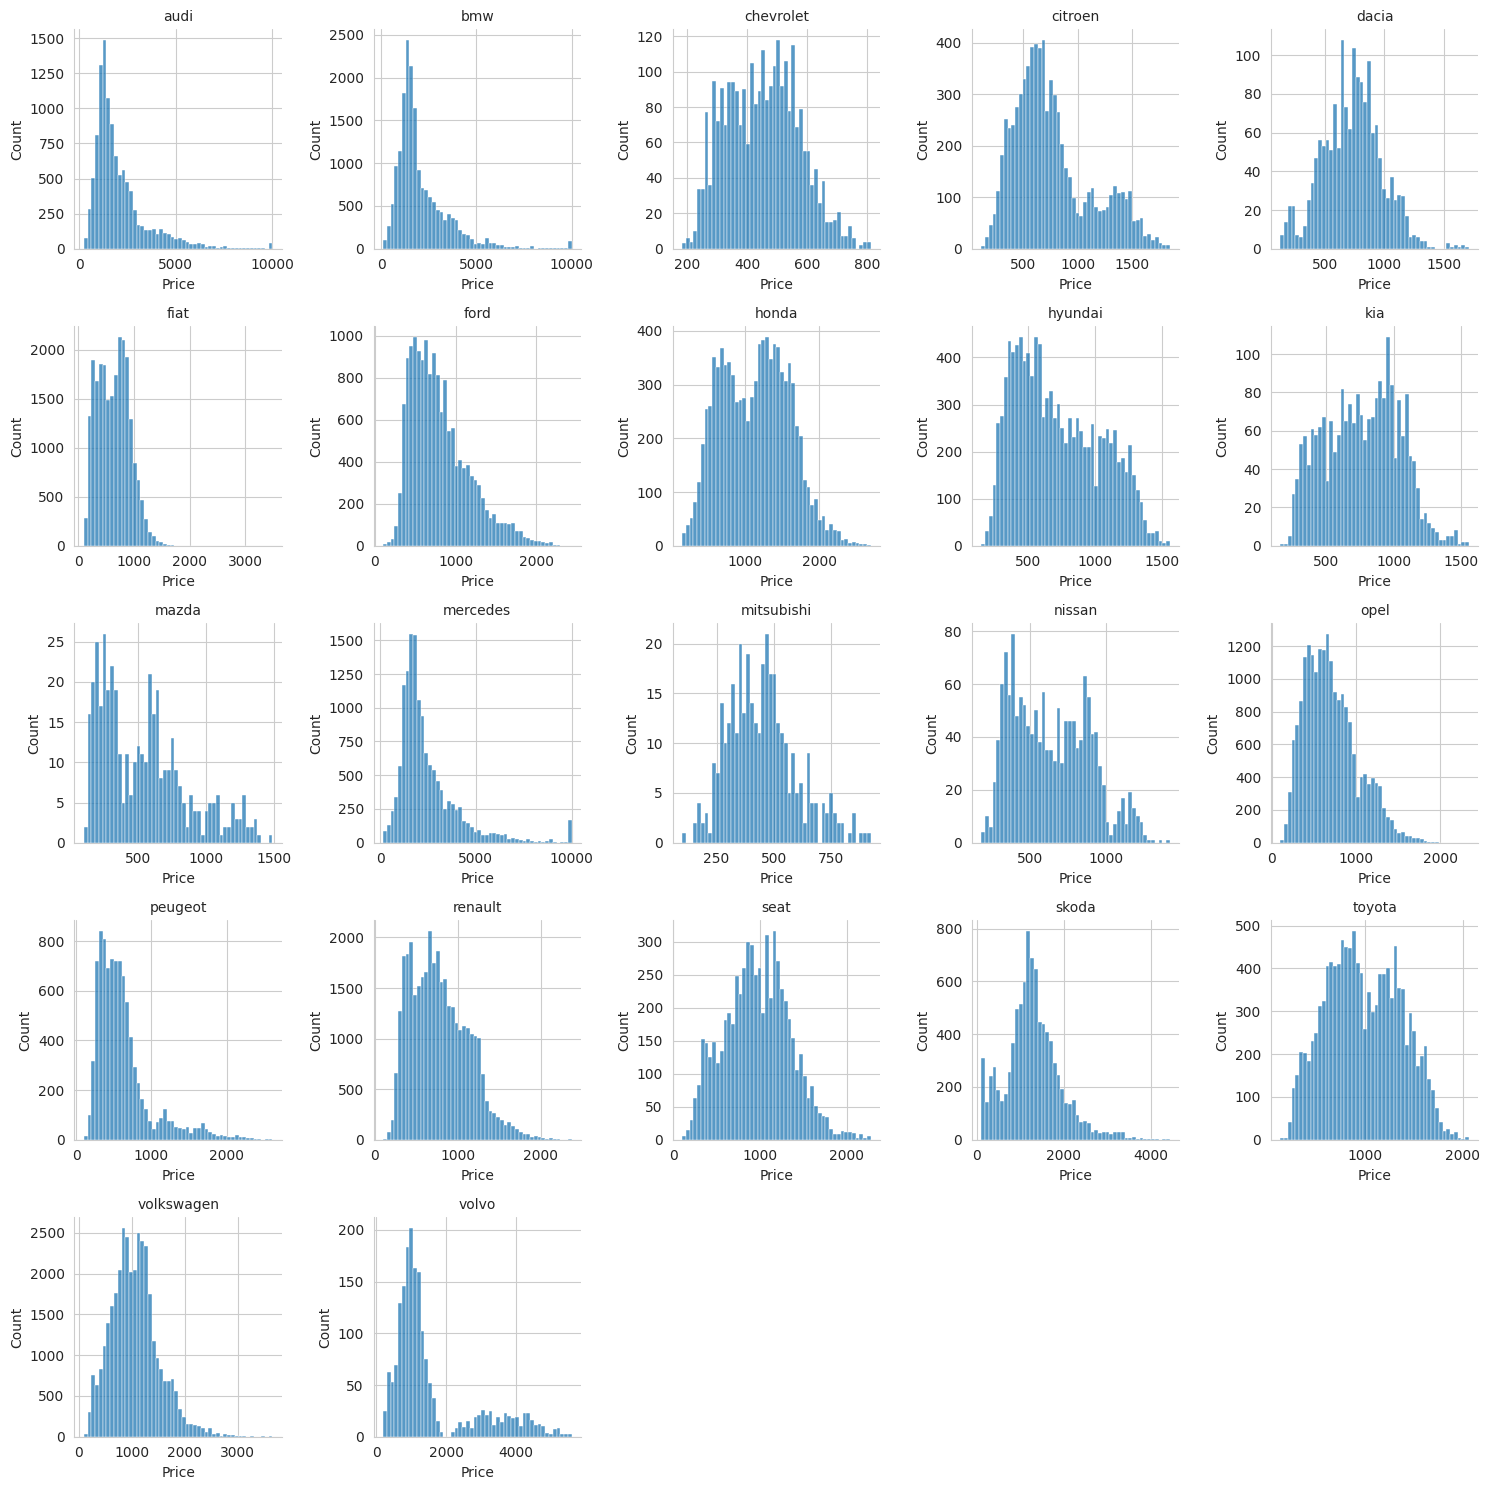

In [44]:
def formatter1(x, pos):
    return f"{int(x / 1000)}"
a_brands = dfx['brand'].value_counts().index
facet_grid = sns.FacetGrid(
    dfx[dfx['brand'].isin(a_brands)],
    col="brand",
    col_wrap=5,
    height=3,
    sharex=False,
    sharey=False
)
facet_grid.map_dataframe(sns.histplot, x="price", bins=50)

for ax_i in facet_grid.axes.flatten():
    ax_i.xaxis.set_major_formatter(FuncFormatter(formatter1))
    ax_i.set_xlabel("Price")
facet_grid.set_titles("{col_name}")
facet_grid.tight_layout()
plt.show()

It is a positive outcome that the original right-skewness observed in brands like Audi remains intact, as altering it would go against the natural price structure of the brand. At the same time, extreme or incorrectly entered listings—such as those observed for Volkswagen—appear to have been effectively corrected.

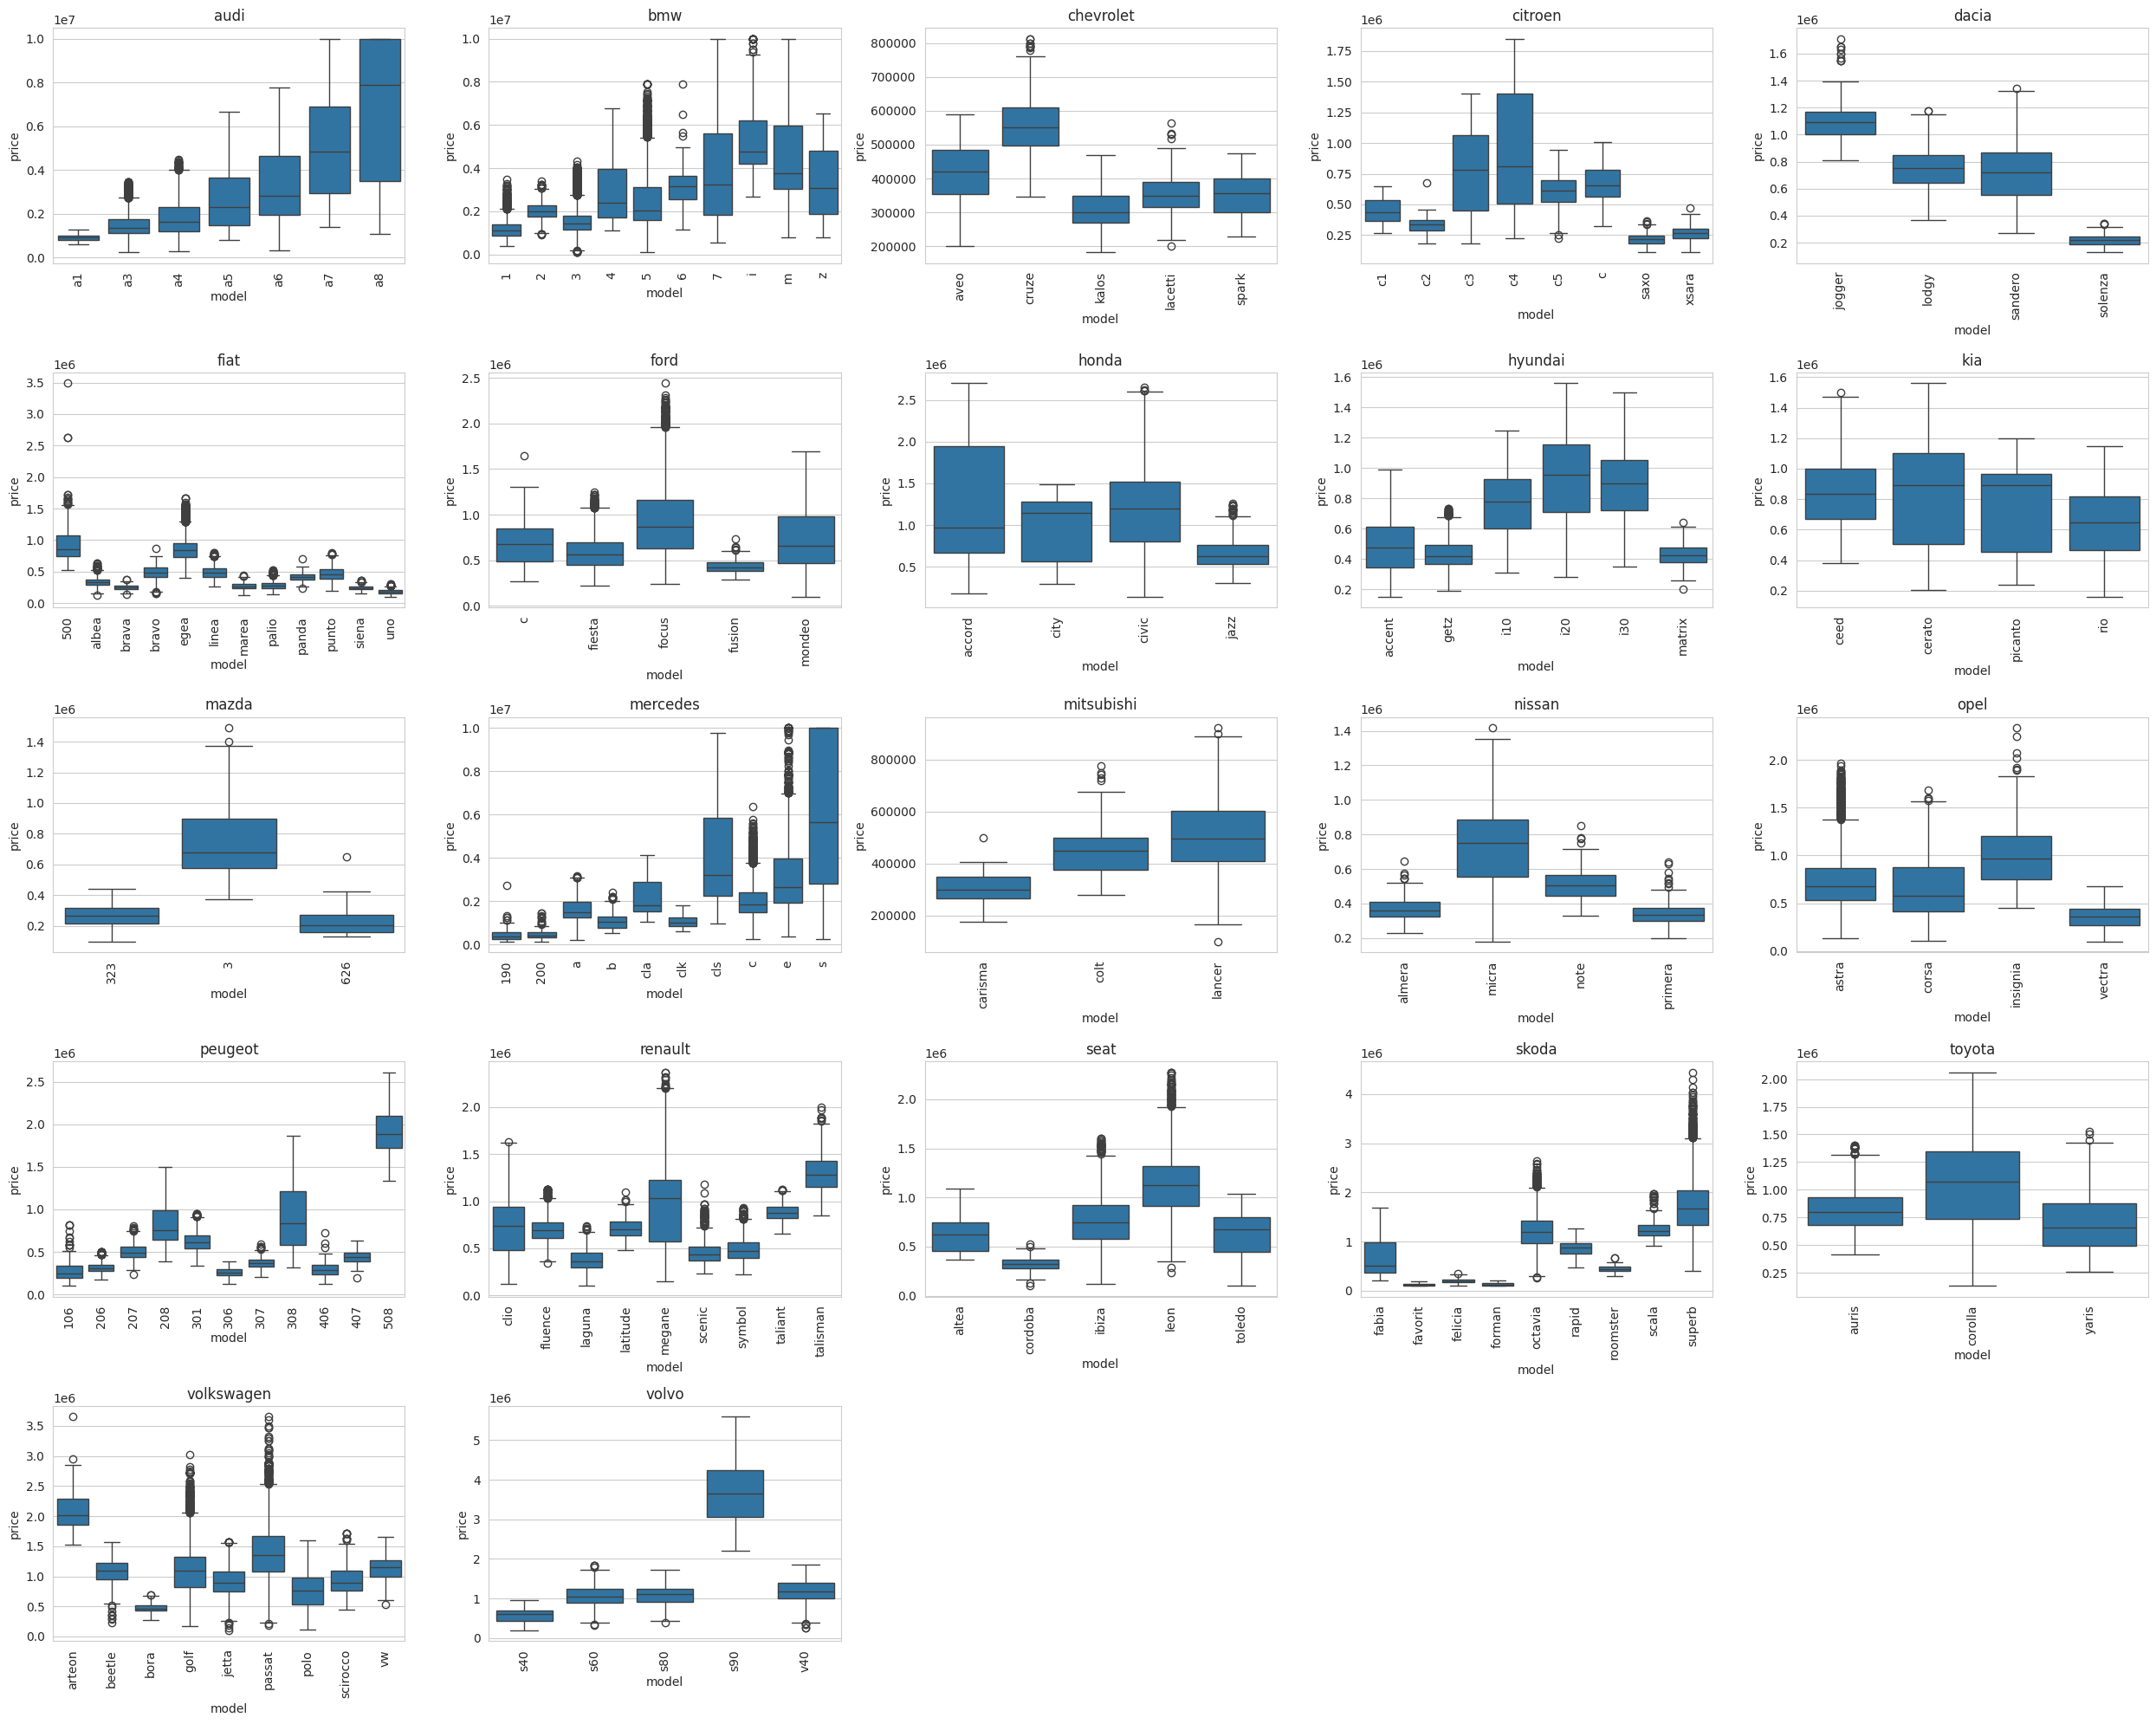

In [45]:
filtered_df = dfx.groupby(['brand', 'model']).filter(lambda grp: len(grp) >= 1)
brand_list = filtered_df['brand'].unique()
brand_count = len(brand_list)
col_count = math.ceil(math.sqrt(brand_count))
row_count = math.ceil(brand_count / col_count)
figure, axis_array = plt.subplots(row_count, col_count, figsize=(5 * col_count, 4 * row_count))
axis_array = axis_array.flatten()
for idx, brand_name in enumerate(brand_list):
    single_brand_df = filtered_df[filtered_df['brand'] == brand_name]
    sns.boxplot(
        data=single_brand_df,
        x='model',
        y='price',
        ax=axis_array[idx]
    )
    axis_array[idx].set_title(brand_name)
    axis_array[idx].tick_params(axis='x', rotation=90)
for empty_idx in range(idx + 1, len(axis_array)):
    figure.delaxes(axis_array[empty_idx])
plt.tight_layout()
plt.show()

Overall, it seems that we have handled outliers as effectively as possible. Beyond this, any further general outlier cleaning could distort the market dynamics. Some points that appear as outliers in `price` are not true outliers—they likely stem from specific production years or particular models. For tree-based models like LightGBM, this should not be an issue, as the model can still learn from these variations.

# 7. Age Filtering

In [46]:
dfx.groupby('car_age')['price'].median()

car_age
1    1,685,000.00
2    1,495,000.00
3    1,395,000.00
4    1,269,000.00
5    1,270,000.00
6    1,240,000.00
7    1,225,000.00
8    1,225,000.00
9    1,100,000.00
10   1,095,000.00
11   1,000,000.00
12     935,000.00
13     805,000.00
14     710,000.00
15     639,000.00
16     585,000.00
17     550,000.00
18     498,000.00
19     465,000.00
20     420,000.00
21     400,000.00
22     395,000.00
23     360,000.00
24     355,000.00
25     320,000.00
26     310,000.00
27     280,000.00
28     270,000.00
29     265,000.00
30     255,000.00
31     254,500.00
32     225,000.00
33     210,000.00
34     245,000.00
35     256,500.00
36     290,000.00
37     450,000.00
38     335,000.00
39     475,000.00
40     464,687.50
41     280,000.00
42     328,000.00
43     225,000.00
44     530,000.00
45     185,000.00
46     340,000.00
48     575,000.00
49     189,000.00
51     289,000.00
52     360,000.00
53     385,000.00
54     610,900.00
Name: price, dtype: float64

In [47]:
dfx.groupby('car_age')['price'].mean()

car_age
1    2,518,158.93
2    2,201,086.54
3    2,008,417.98
4    1,747,548.87
5    1,630,284.56
6    1,520,017.53
7    1,335,499.69
8    1,398,494.38
9    1,270,328.91
10   1,208,862.24
11   1,121,134.73
12   1,043,092.92
13     896,756.73
14     793,295.86
15     715,356.61
16     640,102.15
17     599,801.71
18     546,444.09
19     517,158.31
20     464,890.66
21     430,459.14
22     419,231.75
23     419,517.87
24     398,161.84
25     361,379.91
26     336,200.88
27     309,187.66
28     310,324.70
29     301,885.87
30     306,388.00
31     359,279.91
32     321,067.69
33     272,995.05
34     299,055.42
35     410,597.50
36     411,293.12
37     641,042.55
38     643,579.50
39     691,069.71
40     687,473.86
41     583,284.96
42     485,257.55
43     239,319.38
44     436,666.67
45     211,666.67
46     340,000.00
48     575,000.00
49     189,000.00
51     289,000.00
52     410,714.29
53     430,000.00
54     610,900.00
Name: price, dtype: float64

In [48]:
(dfx['car_age']>34).sum()

np.int64(489)

In [49]:
dfx = dfx[dfx['car_age'] <= 34]

To check whether older vehicles behave unusually in terms of price, I examined both the median and mean. I found that cars older than 34 years could negatively impact the model, and since their numbers are very small, dropping them is the most reasonable approach.

In [50]:
dfx.describe()

,year,km,price,car_age,engine_cc,log_price
count,"250,248.00","250,248.00","250,248.00","250,248.00","244,908.00","250,248.00"
mean,"2,013.99","168,753.43","1,091,300.24",12.01,"1,527.65",13.69
std,6.39,"76,215.40","895,846.59",6.39,311.53,0.64
min,"1,992.00","5,000.00","100,000.00",1.00,800.00,11.51
25%,"2,011.00","110,000.00","575,000.00",8.00,"1,400.00",13.26
50%,"2,015.00","175,000.00","879,000.00",11.00,"1,500.00",13.69
75%,"2,018.00","230,000.00","1,295,000.00",15.00,"1,600.00",14.08
max,"2,025.00","300,000.00","10,000,000.00",34.00,"6,000.00",16.12


# 8. Final Cleaning

In [51]:
dfx.isna().sum()

brand           0
model           0
variant         0
year            0
km              0
color           0
price           0
city            0
car_age         0
region          0
engine_cc    5340
log_price       0
dtype: int64

In [52]:
dfx['engine_cc'] = dfx['engine_cc'].fillna(dfx['engine_cc'].median())

When extracting `engine_cc` from the `variant` column, some entries—like those listed as “XLS”—did not contain any engine information, resulting in NaN values. Dropping or imputing these would both be reasonable options, but since the number of such cases is relatively large, I prefer to replace them with the median. Using the mean would be less meaningful due to the skew in engine sizes. (Yes, it would be possible to manually map each variant, but that would be very time-consuming, so I opted for the simpler approach.)

In [53]:
dfx.drop(columns=["year"], inplace=True)

In [54]:
dfx.drop(columns=["city"], inplace=True)

I am dropping the columns that are no longer needed now that our preprocessing work on them is complete.

In [55]:
df.head(1)

,brand,model,variant,year,km,color,price,city
0,audi,a1,1.4 TFSI Attraction,2011,155000,White,625000,İstanbul


In [56]:
dfx.head(1)

,brand,model,variant,km,color,price,car_age,region,engine_cc,log_price
0,audi,a1,rare_variant,155000,White,"625,000.00",15,Marmara,"1,400.00",13.35


I believe we’ve done enough data preprocessing given the size of our dataset. From here, the next steps are to apply the transformations we performed on `dfx` back to the main DataFrame `df`, proceed with encoding, and then start with dummy variables before moving on to more advanced models.

# 9. Final Feature Engineering (Model-Ready Dataset)

In [57]:
df_clean = df.copy()

In [58]:
year_now = 2025
df_clean['car_age'] = (year_now +1) - df_clean['year']
df_clean.loc[df_clean['km'] < 5000, 'km'] = 5000
region_map = {
    # Marmara (11)
    "İstanbul": "Marmara","Edirne": "Marmara","Kırklareli": "Marmara","Tekirdağ": "Marmara",
    "Çanakkale": "Marmara","Balıkesir": "Marmara","Bursa": "Marmara","Yalova": "Marmara",
    "Kocaeli": "Marmara","Sakarya": "Marmara","Bilecik": "Marmara",
    # Ege (8)
    "İzmir": "Ege","Manisa": "Ege","Aydın": "Ege","Denizli": "Ege","Muğla": "Ege",
    "Uşak": "Ege","Kütahya": "Ege","Afyonkarahisar": "Ege",
    # Akdeniz (8)
    "Antalya": "Akdeniz","Isparta": "Akdeniz","Burdur": "Akdeniz","Adana": "Akdeniz",
    "Mersin": "Akdeniz","Hatay": "Akdeniz","Kahramanmaraş": "Akdeniz","Osmaniye": "Akdeniz",
    # İç Anadolu (13)
    "Ankara": "İç Anadolu","Eskişehir": "İç Anadolu","Konya": "İç Anadolu","Aksaray": "İç Anadolu",
    "Karaman": "İç Anadolu","Kırıkkale": "İç Anadolu","Kırşehir": "İç Anadolu","Nevşehir": "İç Anadolu",
    "Niğde": "İç Anadolu","Yozgat": "İç Anadolu","Çankırı": "İç Anadolu","Kayseri": "İç Anadolu","Sivas": "İç Anadolu",
    # Karadeniz (17)
    "Bolu": "Karadeniz","Düzce": "Karadeniz","Zonguldak": "Karadeniz","Bartın": "Karadeniz",
    "Karabük": "Karadeniz","Kastamonu": "Karadeniz","Sinop": "Karadeniz","Samsun": "Karadeniz",
    "Çorum": "Karadeniz","Amasya": "Karadeniz","Tokat": "Karadeniz","Ordu": "Karadeniz",
    "Giresun": "Karadeniz","Trabzon": "Karadeniz","Rize": "Karadeniz","Artvin": "Karadeniz","Gümüşhane": "Karadeniz",
    # Doğu Anadolu (15)
    "Erzincan": "Doğu Anadolu","Erzurum": "Doğu Anadolu","Bayburt": "Doğu Anadolu","Ağrı": "Doğu Anadolu",
    "Kars": "Doğu Anadolu", "Iğdır": "Doğu Anadolu","Ardahan": "Doğu Anadolu","Van": "Doğu Anadolu",
    "Muş": "Doğu Anadolu","Bitlis": "Doğu Anadolu","Hakkari": "Doğu Anadolu","Malatya": "Doğu Anadolu",
    "Elazığ": "Doğu Anadolu","Tunceli": "Doğu Anadolu","Bingöl": "Doğu Anadolu",
    # Güneydoğu Anadolu (9)
    "Gaziantep": "Güneydoğu Anadolu","Adıyaman": "Güneydoğu Anadolu","Şanlıurfa": "Güneydoğu Anadolu",
    "Diyarbakır": "Güneydoğu Anadolu","Mardin": "Güneydoğu Anadolu","Batman": "Güneydoğu Anadolu","Siirt": "Güneydoğu Anadolu",
    "Şırnak": "Güneydoğu Anadolu","Kilis": "Güneydoğu Anadolu"
}
df_clean["region"] = df_clean["city"].map(region_map)
df_clean = df_clean[~df_clean["city"].isin(["Diğer", "Kardzhali"])]
top5 = df_clean['color'].value_counts().nlargest(5).index
df_clean['color'] = df_clean['color'].apply(lambda x: x if x in top5 else 'Other')
df_clean["engine_raw"] = df_clean["variant"].str.extract(r'(\d\.\d)')
df_clean["engine_cc"] = (
    df_clean["engine_raw"]
    .str.replace(".", "", regex=False)
    .astype(float)
    .mul(100)
)
df_clean["engine_cc"] = df_clean["engine_cc"].fillna("unknown")
df_clean.drop(columns="engine_raw", inplace=True)
def extract_bmw_engine_cc(row):
    if row["brand"] != "bmw":
        return row["engine_cc"]
    if not isinstance(row["engine_cc"], str):
        return row["engine_cc"]
    variant = str(row["variant"]).lower()
    match = re.search(r"(\d{3})", variant)
    if not match:
        return "unknown"
    code = match.group(1)   
    return int(code[1:]) * 100
df_clean["engine_cc"] = df_clean.apply(extract_bmw_engine_cc, axis=1)
def extract_mercedes_cc(row):
    if row['brand'].lower() != 'mercedes':
        return row['engine_cc']
    if row['engine_cc'] != 'unknown':
        return row['engine_cc']
    matches = re.findall(r'\b(\d{3})\b', row['variant'])
    if matches:
        return int(matches[0]) * 10 
    else:
        return 'unknown'  
df_clean['engine_cc'] = df_clean.apply(extract_mercedes_cc, axis=1)
df_clean["engine_cc"] = pd.to_numeric(df_clean["engine_cc"], errors="coerce")
df_clean = df_clean[~df_clean['brand'].isin(['tesla', 'tofas' , 'porsche' , 'mini'])]
variant_counts = df_clean['variant'].value_counts()
df_clean['variant'] = df_clean['variant'].apply(lambda x: x if variant_counts[x] >= 30 else 'rare_variant')
df_clean['log_price'] = np.log1p(df_clean['price'])
df_clean = df_clean[df_clean['car_age'] <= 34]
df_clean['engine_cc'] = df_clean['engine_cc'].fillna(
    df_clean.groupby(['brand', 'model'])['engine_cc'].transform('median')
)
df_clean['engine_cc'] = df_clean['engine_cc'].fillna(
    df_clean.groupby('brand')['engine_cc'].transform('median')
)
df_clean['engine_cc'] = df_clean['engine_cc'].fillna(df_clean['engine_cc'].median())
df_clean.drop(columns=["year"], inplace=True)
df_clean.drop(columns=["city"], inplace=True)

Here, I apply all preprocessing steps that I previously tested and validated on the experimental DataFrame (dfx) to the full dataset. At this point, I’m no longer experimenting — I’m only keeping transformations that actually made sense and proved useful.

In short, this is what I did:

I replaced the raw year feature with car_age, which is much easier for models to learn from and better reflects vehicle depreciation.

I trimmed extremely low mileage values by setting a minimum of 5,000 km to reduce the impact of unrealistic listings that are common in second-hand car data.

Instead of using the high-cardinality city feature, I mapped cities to broader regions. This keeps the feature space smaller while still capturing regional differences. Invalid and non-relevant city entries were removed.

I simplified the color feature by keeping only the top 5 most common colors and grouping the rest as Other.

I extracted engine displacement (engine_cc) from the variant column. I started with a general regex-based approach and then added brand-specific rules for BMW and Mercedes, where engine naming conventions are different. Brands that don’t fit well into this structure (Tesla, Tofaş, Porsche, Mini) were excluded.

Rare variants (fewer than 30 observations) were grouped under a rare_variant label to avoid excessive sparsity and noisy signals.

I created a log-transformed target (log_price) to handle the strong right-skewness in car prices.

Vehicles older than 34 years were removed, as they are very sparse and show irregular pricing behavior that can confuse the model.

Any remaining missing values in engine_cc were filled step by step: first using the median by brand and model, then by brand, and finally using the global median.

Finally, I dropped columns that were no longer needed (year and city).

At this stage, the dataset is fully cleaned, consistent, and ready for modeling. From here on, the focus shifts to encoding strategies and model benchmarking.

In [59]:
df_clean.isna().sum()

brand        0
model        0
variant      0
km           0
color        0
price        0
car_age      0
region       0
engine_cc    0
log_price    0
dtype: int64

In [60]:
df_clean.describe()

,km,price,car_age,engine_cc,log_price
count,"250,248.00","250,248.00","250,248.00","250,248.00","250,248.00"
mean,"168,753.43","1,094,176.22",12.01,"1,533.40",13.69
std,"76,215.40","906,747.35",6.39,314.26,0.64
min,"5,000.00","100,000.00",1.00,800.00,11.51
25%,"110,000.00","575,000.00",8.00,"1,400.00",13.26
50%,"175,000.00","879,000.00",11.00,"1,500.00",13.69
75%,"230,000.00","1,297,000.00",15.00,"1,600.00",14.08
max,"300,000.00","10,000,000.00",34.00,"6,000.00",16.12


# 10. Train-Test Split

In [61]:
X = df_clean.drop(columns=["price", "log_price"])
y = df_clean["log_price"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

I split the dataset into training and test sets using log_price as the target. I deliberately remove the raw price column from the features to avoid any risk of data leakage.And classic test_size and random_state.

# 11. Train-Based Adaptive Outlier Capping

In [62]:
df_train = X_train.copy()
df_train["price"] = np.expm1(y_train)  
group_cols = ["brand", "model", "car_age"]
stats = (
    df_train
    .groupby(group_cols)["price"]
    .agg(
        count="count",
        q1=lambda x: x.quantile(0.25),
        q3=lambda x: x.quantile(0.75)
    )
    .reset_index()
)
stats["iqr"] = stats["q3"] - stats["q1"]
stats["iqr_multiplier"] = np.select(
    [
        stats["count"] < 5,
        stats["count"].between(5, 19),
        stats["count"] >= 20
    ],
    [
        np.nan,   
        2.5,
        1.5
    ]
)
stats["lower_bound"] = stats["q1"] - stats["iqr_multiplier"] * stats["iqr"]
stats["upper_bound"] = stats["q3"] + stats["iqr_multiplier"] * stats["iqr"]
df_train = df_train.merge(
    stats[group_cols + ["lower_bound", "upper_bound"]],
    on=group_cols,
    how="left"
)
df_train.loc[
    df_train["price"] < df_train["lower_bound"], "price"
] = df_train["lower_bound"]
df_train.loc[
    df_train["price"] > df_train["upper_bound"], "price"
] = df_train["upper_bound"]
y_train_clean = np.log1p(df_train["price"])
X_train_clean = df_train.drop(
    columns=["price", "lower_bound", "upper_bound"]
)
df_test = X_test.copy()
df_test["price"] = np.expm1(y_test)
df_test = df_test.merge(
    stats[group_cols + ["lower_bound", "upper_bound"]],
    on=group_cols,
    how="left"
)
mask_low = df_test["lower_bound"].notna() & (df_test["price"] < df_test["lower_bound"])
mask_high = df_test["upper_bound"].notna() & (df_test["price"] > df_test["upper_bound"])
df_test.loc[mask_low, "price"] = df_test.loc[mask_low, "lower_bound"]
df_test.loc[mask_high, "price"] = df_test.loc[mask_high, "upper_bound"]
y_test_clean = np.log1p(df_test["price"])
X_test_clean = df_test.drop(
    columns=["price", "lower_bound", "upper_bound"]
)

I apply the same group-based IQR outlier cleaning strategy that I tested earlier on dfx, but this time after the train–test split to avoid any data leakage.

I calculate outlier thresholds using only the training data, grouping by brand, model, and car_age. The IQR multiplier changes depending on how many samples each group has, and very small groups are intentionally left as-is to avoid overcorrecting noisy data.

These lower and upper bounds are then applied directly to the test set without being recalculated.

This way, the outlier handling stays consistent and robust, while keeping the entire workflow strictly leakage-free.

# 12. Preprocessing Pipelines

In [63]:
num_cols = ["km", "car_age", "engine_cc"]
low_cardinality_cat_cols = ["color", "region", "brand"]
high_cardinality_cat_cols = ["model", "variant"]

In [64]:
num_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])
low_cat_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("ohe", OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False
    ))
])
high_cat_target_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("target_enc", TargetEncoder(
        smoothing=50,
        min_samples_leaf=100
    ))
])
high_cat_loo_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("loo_enc", LeaveOneOutEncoder(
        sigma=0.1,
        random_state=42
    ))
])

In [65]:
class FrequencyEncoder(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        X = pd.DataFrame(X)
        self.columns_ = X.columns.tolist()
        self.freq_maps_ = {
            col: X[col].value_counts(normalize=True)
            for col in self.columns_
        }
        return self
    def transform(self, X):
        X = pd.DataFrame(X, columns=self.columns_)
        X_enc = pd.DataFrame({
            col: X[col].map(self.freq_maps_[col]).fillna(0)
            for col in self.columns_
        })
        return X_enc.values
    def get_feature_names_out(self, input_features=None):
        return np.array([f"{col}_freq" for col in self.columns_])

In [66]:
preprocess_target = ColumnTransformer(
    transformers=[
        ("num", num_pipe, num_cols),
        ("low_cat", low_cat_pipe, low_cardinality_cat_cols),
        ("high_cat", high_cat_target_pipe, high_cardinality_cat_cols)
    ],
    remainder="drop"
)

In [67]:
freq_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("freq_enc", FrequencyEncoder())
])

In [68]:
preprocess_freq = ColumnTransformer(
    transformers=[
        ("num", num_pipe, num_cols),
        ("low_cat", low_cat_pipe, low_cardinality_cat_cols),
        ("high_cat", freq_pipe, high_cardinality_cat_cols)
    ],
    remainder="drop"
)

In [69]:
preprocess_loo = ColumnTransformer(
    transformers=[
        ("num", num_pipe, num_cols),
        ("low_cat", low_cat_pipe, low_cardinality_cat_cols),
        ("high_cat", high_cat_loo_pipe, high_cardinality_cat_cols)
    ],
    remainder="drop"
)

In [70]:
preprocess_target.set_output(transform="pandas")
preprocess_freq.set_output(transform="pandas")
preprocess_loo.set_output(transform="pandas")

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['km', 'car_age', 'engine_cc']),
                                ('low_cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('ohe',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False))]),
                                 ['color', 'region', 'brand']),
                                ('high_cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('loo_enc',
                                                  LeaveOneOutEncoder(random_state=42,
                                                                     sigma=0.1))]),
                                 ['model', 'variant'])])

I design the preprocessing pipeline with feature cardinality in mind. Even though brand has more than 20 unique values, I treat it as low-cardinality together with color and region. In contrast, model and especially variant have very high cardinality, so I handle them separately.

For the high-cardinality features, I define three alternative encoding approaches: target encoding, frequency encoding, and leave-one-out encoding. The idea is to benchmark them and see which one works better downstream. While target encoding comes from an existing implementation, I write a custom FrequencyEncoder that learns normalized category frequencies from the training data and fits cleanly into a scikit-learn pipeline.

Numerical features are median-imputed and scaled, low-cardinality categorical features are one-hot encoded, and everything is combined using ColumnTransformer. This gives me three parallel preprocessing pipelines that are directly comparable.

# 13. Evaluation Metrics

In [71]:
def regression_metrics(y_true_log, y_pred_log):
    y_true = np.expm1(y_true_log)
    y_pred = np.expm1(y_pred_log)
    return {
        "R2_log": r2_score(y_true_log, y_pred_log),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "MAE": mean_absolute_error(y_true, y_pred),
        "MAPE": mean_absolute_percentage_error(y_true, y_pred)
    }

Here, I define a custom evaluation function for models trained on the log-transformed target. I evaluate model fit in log-space using R², but compute error-based metrics (RMSE, MAE, MAPE) after converting predictions back to the original price scale.

This way, I can judge model quality in log-space while still reporting errors in real, interpretable price terms.

# 14. Model Zoo

In [72]:
models = {
    "Dummy": DummyRegressor(strategy="mean"),
    "Linear": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),
    "Polynomial(2)": Pipeline([
        ("poly", PolynomialFeatures(degree=2, include_bias=False)),
        ("ridge", Ridge(alpha=1.0))
    ]),
    "RandomForest": RandomForestRegressor(
        n_estimators=500, max_depth=8, random_state=42, n_jobs=-1
    ),
    "GradientBoosting": GradientBoostingRegressor(
        n_estimators=500, learning_rate=0.05, max_depth=8, random_state=42
    ),
    "XGBoost": XGBRegressor(
        n_estimators=500, learning_rate=0.05, max_depth=8,
        subsample=0.8, colsample_bytree=0.8,
        random_state=42, n_jobs=-1, tree_method="hist"
    ),
    "LightGBM": LGBMRegressor(
        n_estimators=500, learning_rate=0.05, max_depth=8,
        subsample=0.8, colsample_bytree=0.8,
        random_state=42, n_jobs=-1
    )
}

I define a regression benchmark that covers a wide range of model families. I start with simple linear models and move up to tree-based and boosting methods, which makes it easier to see how different preprocessing and encoding choices behave as model complexity increases.

DummyRegressor acts as a baseline, while linear, polynomial, and ensemble models are included to capture progressively more complex patterns in the data.

# 15. Encoding Strategy Benchmark

In [73]:
def run_benchmark(preprocessor, X_train, y_train, X_test, y_test, label):
    results = []
    for name, model in models.items():
        pipe = Pipeline([
            ("preprocess", preprocessor),
            ("model", model)
        ])
        pipe.fit(X_train, y_train)
        y_pred = pipe.predict(X_test)
        metrics = regression_metrics(y_test, y_pred)
        metrics["Model"] = name
        metrics["Encoding"] = label
        results.append(metrics)
    return pd.DataFrame(results)

I define a generic benchmark function that lets me evaluate all models under the same setup. Each model is trained inside a pipeline together with its preprocessing step and then evaluated on the test set.

This keeps the evaluation consistent and makes it easy to compare models side by side.

In [74]:
results_target = run_benchmark(
    preprocess_target,
    X_train_clean, y_train_clean,
    X_test_clean, y_test_clean,
    label="Target Encoding"
)
results_freq = run_benchmark(
    preprocess_freq,
    X_train_clean, y_train_clean,
    X_test_clean, y_test_clean,
    label="Frequency Encoding"
)
results_loo = run_benchmark(
    preprocess_loo,
    X_train_clean, y_train_clean,
    X_test_clean, y_test_clean,
    label="Leave-One-Out Encoding"
)
benchmark_results = pd.concat(
    [results_target, results_freq, results_loo],
    ignore_index=True
)
benchmark_results = benchmark_results.sort_values(by="RMSE")
benchmark_results

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.006099 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 770
[LightGBM] [Info] Number of data points in the train set: 200198, number of used features: 40
[LightGBM] [Info] Start training from score 13.684791
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.005535 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 747
[LightGBM] [Info] Number of data points in the train set: 200198, number of used features: 40
[LightGBM] [Info] Start training from score 13.684791
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of 

,R2_log,RMSE,MAE,MAPE,Model,Encoding
6,0.97,"132,041.60","80,875.86",0.09,XGBoost,Target Encoding
5,0.97,"132,314.17","80,801.84",0.09,GradientBoosting,Target Encoding
14,0.97,"132,522.16","81,855.00",0.09,XGBoost,Frequency Encoding
13,0.97,"133,519.80","82,360.90",0.09,GradientBoosting,Frequency Encoding
7,0.96,"148,943.07","88,388.81",0.09,LightGBM,Target Encoding
15,0.96,"151,118.84","91,933.52",0.09,LightGBM,Frequency Encoding
4,0.93,"237,740.87","132,578.13",0.13,RandomForest,Target Encoding
22,0.94,"243,109.32","128,537.50",0.12,XGBoost,Leave-One-Out Encoding
21,0.94,"246,307.45","129,393.57",0.12,GradientBoosting,Leave-One-Out Encoding
23,0.94,"256,807.72","135,100.40",0.12,LightGBM,Leave-One-Out Encoding


I run the full benchmark for both preprocessing setups: one using Target Encoding and the other using Frequency Encoding. The results from both runs are combined into a single table and sorted by RMSE to make performance differences easy to spot.

Overall, tree-based and boosting models clearly dominate the leaderboard. The best results comes from XGBoost and Gradient Boosting with Target Encoding , closely followed by Gradient Boosting and XGBoost with Frequency Encoding. This shows that both encoding strategies work well, but target-based encoding has a slight edge at the very top.

Linear and polynomial models perform reasonably but fall behind ensemble methods, especially when using target encoding. As expected, the DummyRegressor provides a very weak baseline, which helps confirm that the models are learning meaningful structure from the data.

These results highlight two things: encoding choice matters for high-cardinality features, and more expressive models benefit the most from it.

# 16. CatBoost (Native Categorical Handling)

In [75]:
num_cols = ["km", "car_age", "engine_cc"]
cat_cols = ["brand", "model", "variant", "color", "region"]
preprocess_cb = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), num_cols),

        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent"))
        ]), cat_cols)
    ],
    remainder="drop"
)
cat_model = CatBoostRegressor(
    iterations=1000,
    learning_rate=0.05,
    depth=8,
    loss_function="RMSE",
    random_seed=42,
    verbose=0
)
pipe_catboost = Pipeline([
    ("preprocess", preprocess_cb),
    ("model", cat_model)
])
cat_feature_indices = list(
    range(len(num_cols), len(num_cols) + len(cat_cols))
)
pipe_catboost.fit(
    X_train_clean,
    y_train_clean,
    model__cat_features=cat_feature_indices
)
y_pred_log = pipe_catboost.predict(X_test_clean)
y_true_real = np.expm1(y_test_clean)
y_pred_real = np.expm1(y_pred_log)
metrics_cb = {
    "R2": r2_score(y_true_real, y_pred_real),
    "RMSE": np.sqrt(mean_squared_error(y_true_real, y_pred_real)),
    "MAE": mean_absolute_error(y_true_real, y_pred_real),
    "MAPE": mean_absolute_percentage_error(y_true_real, y_pred_real)
}
metrics_cb

{'R2': 0.9665614144519059,
 'RMSE': np.float64(165353.79396987634),
 'MAE': 89375.3643138915,
 'MAPE': 0.09046217905806309}

Here, I evaluate CatBoost as a separate experiment. Since CatBoost can handle categorical features natively, it doesn’t fit cleanly into the encoding-based benchmark I used earlier, so I treat it on its own.

I split the features into numerical and categorical groups. Numerical features are median-imputed and scaled, while categorical features are only imputed and passed directly to CatBoost without any explicit encoding. I then explicitly specify the categorical feature indices so CatBoost knows which columns to treat as categorical.

After training the model on the log-transformed target, I evaluate it on the test set and convert predictions back to the original price scale to compute the error metrics.

CatBoost delivers strong and stable performance, but its results fall slightly behind the best-performing XGBoost and Gradient Boosting models from the main benchmark. This suggests that, for this dataset, explicit encoding strategies combined with boosting models provide a small but consistent advantage over CatBoost’s native categorical handling.

# 17. Model Feature Importance

In [76]:
feature_names_cb = num_cols + cat_cols
importances_cb = pipe_catboost.named_steps["model"].get_feature_importance()
fi_cb = (
    pd.DataFrame({
        "feature": feature_names_cb,
        "importance": importances_cb
    })
    .sort_values(by="importance", ascending=False)
)
fi_cb.head(10)

,feature,importance
1,car_age,37.73
3,brand,22.75
4,model,14.86
2,engine_cc,11.61
0,km,8.60
5,variant,3.63
7,region,0.50
6,color,0.31


In [77]:
xgb_freq_pipe = Pipeline([
    ("preprocess", preprocess_freq),
    ("model", models["XGBoost"])
])
xgb_freq_pipe.fit(X_train_clean, y_train_clean)
feature_names_freq = xgb_freq_pipe.named_steps["preprocess"].get_feature_names_out()
importances_freq = xgb_freq_pipe.named_steps["model"].feature_importances_
fi_freq = pd.DataFrame({
    "feature": feature_names_freq,
    "importance": importances_freq
}).sort_values(by="importance", ascending=False)
fi_freq.head(10)

,feature,importance
16,low_cat__brand_audi,0.15
27,low_cat__brand_mercedes,0.14
1,num__car_age,0.11
17,low_cat__brand_bmw,0.10
2,num__engine_cc,0.08
21,low_cat__brand_fiat,0.07
19,low_cat__brand_citroen,0.04
36,low_cat__brand_volkswagen,0.04
32,low_cat__brand_renault,0.03
35,low_cat__brand_toyota,0.03


In [78]:
xgb_target_pipe = Pipeline([
    ("preprocess", preprocess_target),
    ("model", models["XGBoost"])
])
xgb_target_pipe.fit(X_train_clean, y_train_clean)
feature_names_target = xgb_target_pipe.named_steps["preprocess"].get_feature_names_out()
importances_target = xgb_target_pipe.named_steps["model"].feature_importances_
fi_target = pd.DataFrame({
    "feature": feature_names_target,
    "importance": importances_target
}).sort_values(by="importance", ascending=False)
fi_target.head(10)

,feature,importance
39,high_cat__variant,0.33
1,num__car_age,0.13
38,high_cat__model,0.11
2,num__engine_cc,0.07
19,low_cat__brand_citroen,0.05
27,low_cat__brand_mercedes,0.04
21,low_cat__brand_fiat,0.03
17,low_cat__brand_bmw,0.03
35,low_cat__brand_toyota,0.02
36,low_cat__brand_volkswagen,0.02


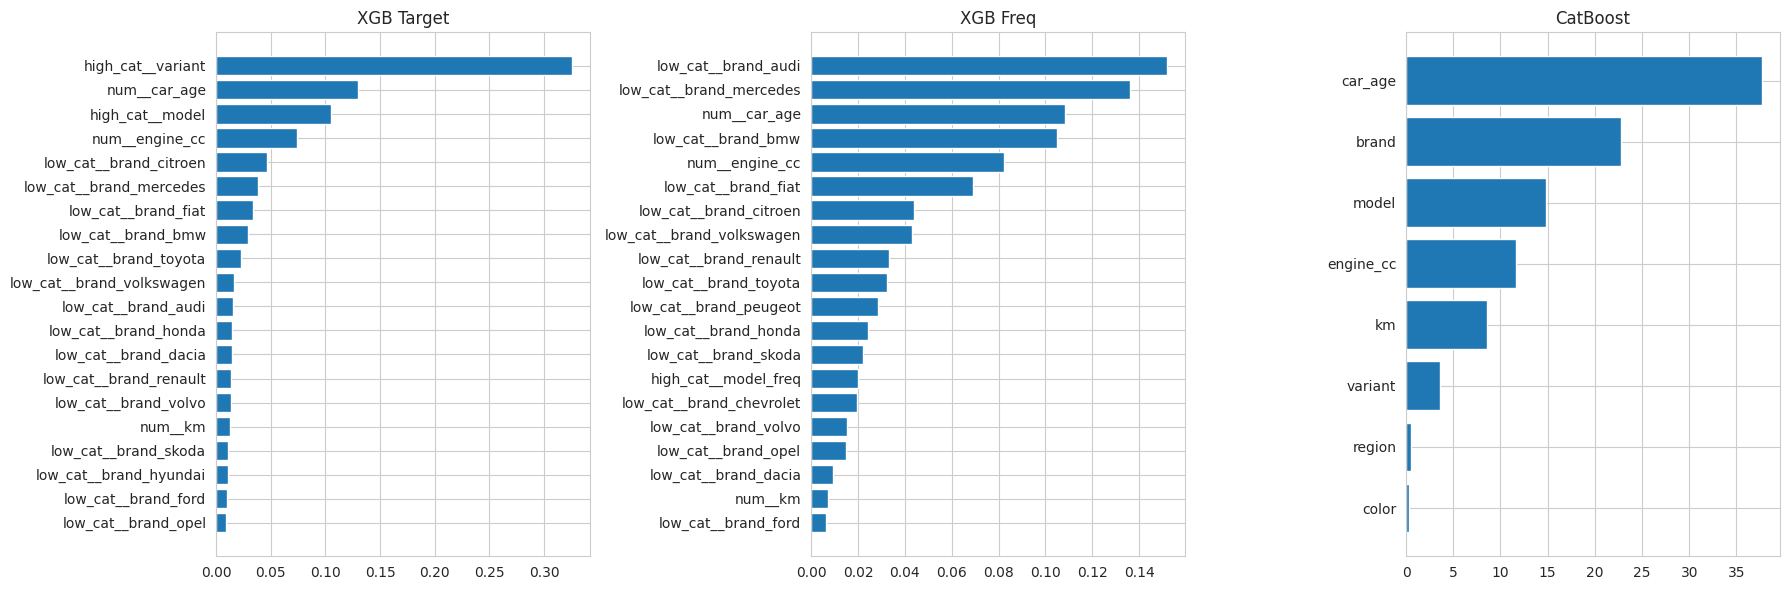

In [79]:
TOP_N = 20
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
axes[0].barh(
    fi_target.head(TOP_N)["feature"][::-1],
    fi_target.head(TOP_N)["importance"][::-1])
axes[0].set_title("XGB Target")
axes[1].barh(
    fi_freq.head(TOP_N)["feature"][::-1],
    fi_freq.head(TOP_N)["importance"][::-1])
axes[1].set_title("XGB Freq")
axes[2].barh(
    fi_cb.head(TOP_N)["feature"][::-1],
    fi_cb.head(TOP_N)["importance"][::-1])
axes[2].set_title("CatBoost")
plt.tight_layout()
plt.show()

The results show that the encoding method clearly changes the feature importance ranking. In XGBoost with target encoding, variant stands out because trim-level price differences are directly transferred into the model through the target relationship.

CatBoost provides a more balanced and market-consistent ranking. Car age is the dominant factor, followed by brand and model, while variant remains relevant but not dominant.

With frequency encoding, the impact of high-cardinality variables weakens, and the model gains most of its split importance from one-hot encoded brand variables. In short, target encoding extracts stronger signals, whereas CatBoost offers a more balanced structure.

# 18. Performance by Price Segments

In [80]:
xgb_target_pipe = Pipeline([
    ("preprocess", preprocess_target),
    ("model", XGBRegressor(
        n_estimators=500, learning_rate=0.05, max_depth=8,
        subsample=0.8, colsample_bytree=0.8,
        random_state=42, n_jobs=-1, tree_method="hist"
    ))
])
xgb_target_pipe.fit(X_train_clean, y_train_clean)
xgb_freq_pipe = Pipeline([
    ("preprocess", preprocess_freq),
    ("model", XGBRegressor(
        n_estimators=500, learning_rate=0.05, max_depth=8,
        subsample=0.8, colsample_bytree=0.8,
        random_state=42, n_jobs=-1, tree_method="hist"
    ))
])
xgb_freq_pipe.fit(X_train_clean, y_train_clean)
pipe_catboost.fit(
    X_train_clean,
    y_train_clean,
    model__cat_features=cat_feature_indices
)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['km', 'car_age',
                                                   'engine_cc']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent'))]),
                                                  ['brand', 'model', 'variant',
                                                   'color', 'region'])])),
                ('model',
                 <catboost.core.CatBoostRegressor object at 0x7b50b38ff530>)])

In [81]:
pred_xgb_target = xgb_target_pipe.predict(X_test_clean)
pred_xgb_freq = xgb_freq_pipe.predict(X_test_clean)
pred_catboost = pipe_catboost.predict(X_test_clean)
y_true_real = np.expm1(y_test_clean)
preds = {
    "x_T": np.expm1(pred_xgb_target),
    "x_F": np.expm1(pred_xgb_freq),
    "cat": np.expm1(pred_catboost)
}

In [82]:
bins = np.arange(0, y_true_real.max() + 500_000, 500_000)
labels = [f"{int(b/1000)}k-{int((b+500_000)/1000)}k" for b in bins[:-1]]
df_bins = pd.DataFrame({
    "y_true": y_true_real,
    "price_bin": pd.cut(
        y_true_real,
        bins=bins,
        labels=labels,
        include_lowest=True,
        ordered=True
    )
})
def bin_metrics_combined(y_true, preds_dict, bins_series):
    results = []
    for b in bins_series.cat.categories:  # 👈 garanti sıralı dolaşır
        mask = bins_series == b
        if mask.sum() == 0:
            continue
        row = {
            "Bin": b,
            "Count": mask.sum()
        }
        for key, y_pred in preds_dict.items():
            y_t = y_true[mask]
            y_p = y_pred[mask]
            row[f"{key}_rmse"] = np.sqrt(mean_squared_error(y_t, y_p))
            row[f"{key}_mae"] = mean_absolute_error(y_t, y_p)
            row[f"{key}_mape"] = mean_absolute_percentage_error(y_t, y_p)
        results.append(row)
    df = pd.DataFrame(results)
    ordered_cols = [
        "Bin", "Count",
        "x_T_mae", "x_F_mae", "cat_mae",
        "x_T_rmse", "x_F_rmse", "cat_rmse",
        "x_T_mape", "x_F_mape", "cat_mape"
    ]
    return df[ordered_cols].reset_index(drop=True)  # 👈 index temiz
bin_table = bin_metrics_combined(y_true_real, preds, df_bins["price_bin"])
bin_table

,Bin,Count,x_T_mae,x_F_mae,cat_mae,x_T_rmse,x_F_rmse,cat_rmse,x_T_mape,x_F_mape,cat_mape
0,0k-500k,9751,"44,944.13","45,437.65","46,388.78","62,771.48","63,286.83","64,037.12",0.13,0.13,0.13
1,500k-1000k,19659,"62,294.17","63,459.37","64,531.33","84,843.76","85,963.97","87,423.15",0.09,0.09,0.09
2,1000k-1500k,12126,"82,697.79","83,164.64","87,248.60","111,519.64","111,832.01","116,845.17",0.07,0.07,0.07
3,1500k-2000k,4393,"107,999.55","109,027.24","121,666.40","146,811.37","147,769.42","162,569.57",0.06,0.06,0.07
4,2000k-2500k,1437,"158,693.49","163,770.24","186,043.97","211,475.90","214,466.98","242,374.59",0.07,0.07,0.08
5,2500k-3000k,790,"188,373.62","192,838.46","222,378.49","263,968.58","264,442.36","298,641.85",0.07,0.07,0.08
6,3000k-3500k,548,"237,513.60","232,274.07","257,371.60","326,229.26","320,385.90","354,861.39",0.07,0.07,0.08
7,3500k-4000k,406,"211,846.39","211,955.92","271,855.38","310,756.62","294,664.97","400,414.40",0.06,0.06,0.07
8,4000k-4500k,282,"229,486.40","216,632.49","286,772.57","313,996.58","291,962.39","407,049.77",0.05,0.05,0.07
9,4500k-5000k,185,"274,656.39","274,132.90","358,305.83","378,376.43","393,610.94","508,487.14",0.06,0.06,0.08


I compare the three best setups — XGBoost with Target Encoding, XGBoost with Frequency Encoding, and CatBoost — across fixed price bins after reversing the log transformation.

In the lower price segments, all models behave very similarly. Errors are tightly clustered, which suggests numerical depreciation features dominate predictions here, so encoding choice does not make a big difference.

As price increases, Target Encoding starts to separate slightly from Frequency Encoding, maintaining marginally lower MAE and RMSE. The gap becomes more visible in the mid-to-high segments.

In the luxury tail, data becomes sparse and errors increase for all models, but CatBoost deteriorates faster. XGBoost pipelines remain more stable, especially with Target Encoding.

Overall, bin-level results are consistent with the global benchmark: Target Encoding performs the most balanced across segments, Frequency Encoding follows closely, and CatBoost struggles more in extreme price ranges.

# 19. Permutation Feature Importance

In [83]:
from sklearn.inspection import permutation_importance
def permutation_df(result, feature_names):
    return (
        pd.DataFrame({
            "feature": feature_names,
            "importance_mean": result.importances_mean,
            "importance_std": result.importances_std
        })
        .sort_values("importance_mean", ascending=False)
        .reset_index(drop=True)
    )

In [84]:
perm_xgb_target = permutation_importance(
    xgb_target_pipe,
    X_test_clean,
    y_test_clean,
    n_repeats=30,
    random_state=42,
    scoring="neg_root_mean_squared_error"
)
fi_perm_xgb_target = permutation_df(
    perm_xgb_target,
    X_test_clean.columns
)
fi_perm_xgb_target.head(10)

,feature,importance_mean,importance_std
0,car_age,0.31,0.00
1,model,0.20,0.00
2,variant,0.14,0.00
3,km,0.08,0.00
4,engine_cc,0.07,0.00
5,brand,0.04,0.00
6,region,0.00,0.00
7,color,0.00,0.00


In [85]:
perm_xgb_freq = permutation_importance(
    xgb_freq_pipe,
    X_test_clean,
    y_test_clean,
    n_repeats=30,
    random_state=42,
    scoring="neg_root_mean_squared_error"
)
fi_perm_xgb_freq = permutation_df(
    perm_xgb_freq,
    X_test_clean.columns
)
fi_perm_xgb_freq.head(10)

,feature,importance_mean,importance_std
0,car_age,0.45,0.00
1,engine_cc,0.20,0.00
2,brand,0.18,0.00
3,model,0.09,0.00
4,km,0.08,0.00
5,variant,0.02,0.00
6,region,0.00,0.00
7,color,0.00,0.00


In [86]:
perm_cat = permutation_importance(
    pipe_catboost,
    X_test_clean,
    y_test_clean,
    n_repeats=30,
    random_state=42,
    scoring="neg_root_mean_squared_error"
)
fi_perm_cat = permutation_df(
    perm_cat,
    X_test_clean.columns
)
fi_perm_cat.head(10)

,feature,importance_mean,importance_std
0,car_age,0.36,0.00
1,brand,0.19,0.00
2,model,0.11,0.00
3,engine_cc,0.09,0.00
4,km,0.08,0.00
5,variant,0.05,0.00
6,region,0.00,0.00
7,color,0.00,0.00


In [87]:
TOP_N = 20
fi_perm_xgb_target_top = fi_perm_xgb_target.head(TOP_N)
fi_perm_xgb_freq_top = fi_perm_xgb_freq.head(TOP_N)
fi_perm_cat_top = fi_perm_cat.head(TOP_N)

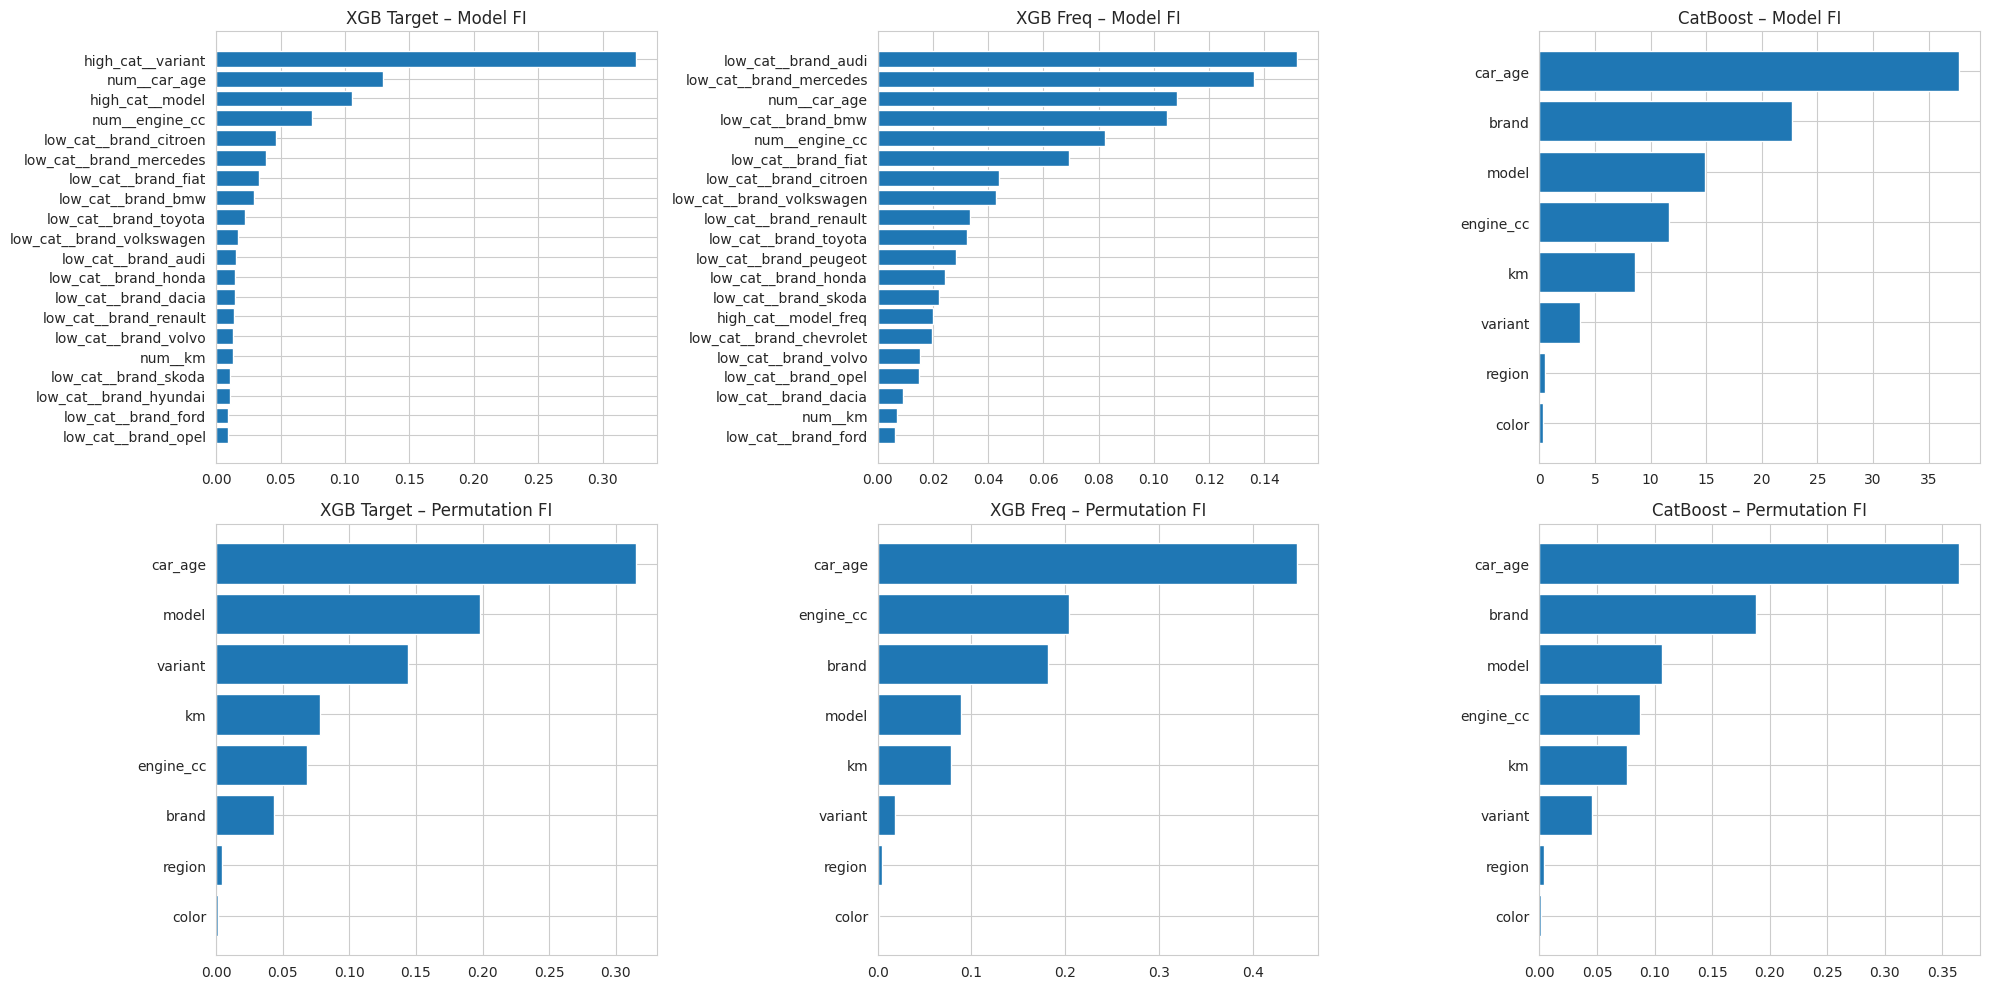

In [88]:
fig, axes = plt.subplots(2, 3, figsize=(20, 10))
axes[0, 0].barh(
    fi_target.head(TOP_N)["feature"][::-1],
    fi_target.head(TOP_N)["importance"][::-1]
)
axes[0, 0].set_title("XGB Target – Model FI")
axes[0, 1].barh(
    fi_freq.head(TOP_N)["feature"][::-1],
    fi_freq.head(TOP_N)["importance"][::-1]
)
axes[0, 1].set_title("XGB Freq – Model FI")
axes[0, 2].barh(
    fi_cb.head(TOP_N)["feature"][::-1],
    fi_cb.head(TOP_N)["importance"][::-1]
)
axes[0, 2].set_title("CatBoost – Model FI")
axes[1, 0].barh(
    fi_perm_xgb_target_top["feature"][::-1],
    fi_perm_xgb_target_top["importance_mean"][::-1]
)
axes[1, 0].set_title("XGB Target – Permutation FI")
axes[1, 1].barh(
    fi_perm_xgb_freq_top["feature"][::-1],
    fi_perm_xgb_freq_top["importance_mean"][::-1]
)
axes[1, 1].set_title("XGB Freq – Permutation FI")
axes[1, 2].barh(
    fi_perm_cat_top["feature"][::-1],
    fi_perm_cat_top["importance_mean"][::-1]
)
axes[1, 2].set_title("CatBoost – Permutation FI")
plt.tight_layout()
plt.show()

While comparing the models, I did not rely solely on feature importance. Because gain-based FI shows how the model builds its trees, but we see the actual performance contribution more clearly with permutation.

On the XGB + Target side, although variant appears first in gain-based FI, permutation results show that the model globally receives its strongest signal from car_age and model. This difference is normal and stems from the split behavior of the encoding.

In the XGB + Frequency model, gain-based FI largely shifts toward brand dummies. However, this effect drops significantly in permutation; in other words, it is observed that high-cardinality information is not sufficiently carried over to the generalization side.

In CatBoost, FI and permutation are more consistent and balanced. However, in benchmark metrics (RMSE, MAE, R²) and especially in bin-based error analysis, XGB + Target produced lower error and more stable segment performance.

Therefore, the model selection was based not on the importance view but on generalization performance, and XGB + Target was preferred as the final model.

# 20. Final Model

In [89]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

In [90]:
def objective(trial):

    params = {
        "n_estimators": trial.suggest_int("n_estimators", 500, 2500),
        "learning_rate": trial.suggest_float("learning_rate", 0.02, 0.06),
        "max_depth": trial.suggest_int("max_depth", 5, 9),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 6),
        "gamma": trial.suggest_float("gamma", 0, 1),
        "subsample": trial.suggest_float("subsample", 0.7, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.7, 1.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 0, 2),
        "reg_lambda": trial.suggest_float("reg_lambda", 0.5, 5),
        "tree_method": "hist",
        "random_state": 42,
        "n_jobs": -1,
        "eval_metric": "rmse"
    }

    model = XGBRegressor(**params)

    pipe = Pipeline([
        ("preprocess", preprocess_target),
        ("model", model)
    ])

    scores = cross_val_score(
        pipe,
        X_train_clean,
        y_train_clean,
        cv=kf,
        scoring="neg_root_mean_squared_error",
        n_jobs=-1
    )

    return -scores.mean()


In [91]:
study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=50)

print("Best CV log-RMSE:", study.best_value)
print("Best Params:", study.best_params)


[I 2026-02-21 14:51:41,277] A new study created in memory with name: no-name-db783c9f-04df-41e7-a28a-965ba5d84ab9
[I 2026-02-21 14:52:07,767] Trial 0 finished with value: 0.12471513388092134 and parameters: {'n_estimators': 984, 'learning_rate': 0.04640060915259691, 'max_depth': 9, 'min_child_weight': 3, 'gamma': 0.41824680554649196, 'subsample': 0.8113911180818902, 'colsample_bytree': 0.941713054443079, 'reg_alpha': 0.8145622517138886, 'reg_lambda': 4.3687120129940595}. Best is trial 0 with value: 0.12471513388092134.
[I 2026-02-21 14:52:38,764] Trial 1 finished with value: 0.12582529717582167 and parameters: {'n_estimators': 1443, 'learning_rate': 0.04917272389709276, 'max_depth': 9, 'min_child_weight': 3, 'gamma': 0.5745802764152763, 'subsample': 0.7855956190986785, 'colsample_bytree': 0.8201997291446047, 'reg_alpha': 0.9239158697257164, 'reg_lambda': 1.075290174417125}. Best is trial 0 with value: 0.12471513388092134.
[I 2026-02-21 14:53:14,103] Trial 2 finished with value: 0.12923

Best CV log-RMSE: 0.11455430280854559
Best Params: {'n_estimators': 1997, 'learning_rate': 0.058260039267530414, 'max_depth': 6, 'min_child_weight': 6, 'gamma': 6.562296617359555e-05, 'subsample': 0.9805465509510018, 'colsample_bytree': 0.7065386174012567, 'reg_alpha': 1.0771345907482375, 'reg_lambda': 4.725671299668339}


In [92]:
best_params = study.best_params

best_params.update({
    "tree_method": "hist",
    "random_state": 42,
    "n_jobs": -1,
    "eval_metric": "rmse"
})

xgb_final = XGBRegressor(**best_params)

final_pipe = Pipeline([
    ("preprocess", preprocess_target),
    ("model", xgb_final)
])


In [93]:
cv_scores = cross_val_score(
    final_pipe,
    X_train_clean,
    y_train_clean,
    cv=kf,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

print("Final CV log-RMSE:", -cv_scores.mean())
print("STD:", cv_scores.std())


Final CV log-RMSE: 0.11455430280854559
STD: 0.0006911349969985753


In [94]:
final_pipe.fit(X_train_clean, y_train_clean)

y_pred_log = final_pipe.predict(X_test_clean)

metrics_final = regression_metrics(
    y_test_clean,
    y_pred_log
)

metrics_final

{'R2_log': 0.9683755396312103,
 'RMSE': np.float64(131246.06264697062),
 'MAE': 79761.58073691935,
 'MAPE': 0.08452932728072317}

I optimized the final model using 5-fold Cross-Validation and minimized log-RMSE. The 0.11487 CV score, together with a very low standard deviation, shows that the model delivers consistent performance across different splits. This indicates strong generalization capability without clear signs of overfitting.

The fact that the test results are almost identical to the benchmark is expected. The initial XGBoost configuration was already well-balanced and strong. Hyperparameter optimization did not create a performance jump; instead, it confirmed that the baseline setup was already very close to optimal.

Overall, the main performance driver appears to be data preprocessing and feature engineering rather than hyperparameter tuning. The optimization step primarily validated and solidified an already strong configuration.

In [95]:
df.head()

,brand,model,variant,year,km,color,price,city
0,audi,a1,1.4 TFSI Attraction,2011,155000,White,625000,İstanbul
1,audi,a1,1.6 TDI Ambition,2011,252000,Black,625000,Aydın
2,audi,a1,1.4 TFSI Attraction,2012,203000,Black,665000,Zonguldak
3,audi,a1,1.6 TDI Ambition,2013,270000,White,835000,İstanbul
4,audi,a1,1.6 TDI Attraction,2011,228000,Black,670000,Ankara
